In [3]:
!kaggle datasets download -d yasserh/song-popularity-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/song-popularity-dataset
License(s): CC0-1.0
  0% 0.00/805k [00:00<?, ?B/s]
100% 805k/805k [00:00<00:00, 755MB/s]


In [4]:
import zipfile

with zipfile.ZipFile("song-popularity-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("song-popularity")

In [5]:
import os
os.listdir("song-popularity")

['song_data.csv']

Using Regression Models

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

import pickle

In [7]:
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

import sklearn
print(sklearn.__version__)

2.2.2
2.0.2
0.13.2
1.6.1


In [8]:
data = pd.read_csv('/content/song-popularity/song_data.csv')
data

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
0,Boulevard of Broken Dreams,73,262333,0.005520,0.496,0.682,0.000029,8,0.0589,-4.095,1,0.0294,167.060,4,0.474
1,In The End,66,216933,0.010300,0.542,0.853,0.000000,3,0.1080,-6.407,0,0.0498,105.256,4,0.370
2,Seven Nation Army,76,231733,0.008170,0.737,0.463,0.447000,0,0.2550,-7.828,1,0.0792,123.881,4,0.324
3,By The Way,74,216933,0.026400,0.451,0.970,0.003550,0,0.1020,-4.938,1,0.1070,122.444,4,0.198
4,How You Remind Me,56,223826,0.000954,0.447,0.766,0.000000,10,0.1130,-5.065,1,0.0313,172.011,4,0.574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18830,Let It Breathe,60,159645,0.893000,0.500,0.151,0.000065,11,0.1110,-16.107,1,0.0348,113.969,4,0.300
18831,Answers,60,205666,0.765000,0.495,0.161,0.000001,11,0.1050,-14.078,0,0.0301,94.286,4,0.265
18832,Sudden Love (Acoustic),23,182211,0.847000,0.719,0.325,0.000000,0,0.1250,-12.222,1,0.0355,130.534,4,0.286
18833,Gentle on My Mind,55,352280,0.945000,0.488,0.326,0.015700,3,0.1190,-12.020,1,0.0328,106.063,4,0.323


# 📊 Dataset Overview

1️⃣ song_name (object)

- Name of the song

- ❌ Not useful for regression directly

- You should drop this column before training
<br>

2️⃣ song_popularity (int64)

- Range: typically 0–100

- Higher value = more popular song

- This is what you are trying to predict using **Linear Regression.**
<br>

3️⃣ song_duration_ms (int)

- Duration of song in milliseconds

- Example: 262333 ms ≈ 4.3 minutes

- Might have slight impact on popularity

- 💡 You can convert it into minutes if needed for interpretation.
<br>

4️⃣ acousticness (0–1)

- 0 → Not acoustic

- 1 → Fully acoustic

- Measures how acoustic the track sounds
<br>

5️⃣ danceability (0–1)

- How suitable a track is for dancing

- Based on tempo, rhythm stability, beat strength

- Higher danceability → often more mainstream appeal
<br>

6️⃣ energy (0–1)

- Intensity and activity level

- High energy → fast, loud, noisy songs

- Low energy → calm, soft songs
<br>

7️⃣ instrumentalness (0–1)

- 0 → Has vocals

- 1 → Pure instrumental

- Most popular songs usually have vocals.
<br>

8️⃣ key (0–11)

- Musical key of the track

- 0 = C, 1 = C#, etc.

- This is categorical in nature
<br>

9️⃣ liveness (0–1)

- Probability that song was recorded live

- High value → likely live recording
<br>

🔟 loudness (negative dB values)

- Measured in decibels (dB)

- Typically ranges from -60 to 0

- Higher (closer to 0) → louder track

- Very important feature in music analytics.
<br>

1️⃣1️⃣ audio_mode (0 or 1)

- 0 → Minor

- 1 → Major

- Binary categorical feature
<br>

1️⃣2️⃣ speechiness (0–1)

- Measures spoken words in track

- High → rap, podcast-like

- Low → music-focused
<br>

1️⃣3️⃣ tempo

- Beats per minute (BPM)

- Example:

  - 60–90 → slow

  - 100–130 → pop range

  - 150+ → fast
<br>

1️⃣4️⃣ time_signature

- Beats per bar

- Most songs = 4

- Discrete categorical feature
<br>

1️⃣5️⃣ audio_valence (0–1)

- Musical positivity

- 0 → sad

- 1 → happy

- Often correlates with listener mood.
<br>


In [9]:
data.shape

(18835, 15)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18835 entries, 0 to 18834
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   song_name         18835 non-null  object 
 1   song_popularity   18835 non-null  int64  
 2   song_duration_ms  18835 non-null  int64  
 3   acousticness      18835 non-null  float64
 4   danceability      18835 non-null  float64
 5   energy            18835 non-null  float64
 6   instrumentalness  18835 non-null  float64
 7   key               18835 non-null  int64  
 8   liveness          18835 non-null  float64
 9   loudness          18835 non-null  float64
 10  audio_mode        18835 non-null  int64  
 11  speechiness       18835 non-null  float64
 12  tempo             18835 non-null  float64
 13  time_signature    18835 non-null  int64  
 14  audio_valence     18835 non-null  float64
dtypes: float64(9), int64(5), object(1)
memory usage: 2.2+ MB


In [11]:
data.dtypes

,0
song_name,object
song_popularity,int64
song_duration_ms,int64
acousticness,float64
danceability,float64
energy,float64
instrumentalness,float64
key,int64
liveness,float64
loudness,float64


This dataset has numerical and categorical features:

🔹 Numerical Continuous

- song_duration_ms

- acousticness

- danceability

- energy

- instrumentalness

- liveness

- loudness

- speechiness

- tempo

- audio_valence

🔹 Categorical (should consider encoding)

- key

- audio_mode

- time_signature

# Missing Values and Duplicates

In [12]:
data.isna().sum()

,0
song_name,0
song_popularity,0
song_duration_ms,0
acousticness,0
danceability,0
energy,0
instrumentalness,0
key,0
liveness,0
loudness,0


In [13]:
print("No. of Duplicates:",data.duplicated().sum())

No. of Duplicates: 3909


In [14]:
data[data.duplicated()]

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
173,Sex on Fire,81,203346,0.00172,0.542,0.905,0.010400,9,0.1360,-5.653,1,0.0540,153.398,4,0.374
179,Use Somebody,79,230760,0.00552,0.276,0.715,0.000417,0,0.2010,-5.356,1,0.0432,137.028,4,0.173
212,Hips Don't Lie,84,218093,0.28400,0.778,0.824,0.000000,10,0.4050,-5.892,0,0.0712,100.024,4,0.756
414,Hotel California - Remastered,83,391376,0.00574,0.579,0.508,0.000494,2,0.0575,-9.484,1,0.0270,147.125,4,0.609
421,Me and Bobby McGee,69,271333,0.30200,0.453,0.464,0.000060,2,0.1520,-10.960,1,0.0431,93.190,4,0.658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18797,The Time I've Wasted,63,213249,0.79600,0.473,0.250,0.000088,5,0.1010,-11.263,1,0.0304,145.027,4,0.261
18811,Oceans,69,216186,0.27400,0.404,0.480,0.000009,9,0.1320,-8.906,0,0.0303,129.162,3,0.200
18817,Life Is Confusing,64,171413,0.95500,0.373,0.216,0.001050,1,0.0739,-11.410,1,0.0326,129.030,4,0.496
18826,Call It Dreaming,67,231760,0.61000,0.519,0.515,0.000057,5,0.1070,-9.448,1,0.0310,80.329,4,0.714


After seeing the data, we've:
- Entire row duplicate

- Same song_name + Different audio features

- Same song_name + Same Audio Features but Different Popularity

## ✅ STEP 1 — Check Exact Row Duplicates

These are rows where every single column is identical. As they add no new information so we will drop them.

In [15]:
data.duplicated().sum()

np.int64(3909)

In [16]:
data = data.drop_duplicates()

In [17]:
data.duplicated().sum()

np.int64(0)

## ✅ STEP 2 — Same song_name but Different Audio Features

If same song_name has:

- Different energy

- Different tempo

- Different loudness
<br>

That likely means:

- Different versions

- Remix

- Live version

- Acoustic version

- Data source variation

If Same song_name + Different audio features we should KEEP them.

Because regression assumes each row = one independent observation.

Even if same name, if features differ → treat as different samples.

## ✅ STEP 3 — Same Audio Features but Different Popularity

That creates noise in regression.

In [18]:
# the names of all the numerical columns that represent the audio features of a song.
feature_cols = [
    'song_duration_ms', 'acousticness', 'danceability', 'energy',
    'instrumentalness', 'key', 'liveness', 'loudness',
    'audio_mode', 'speechiness', 'tempo',
    'time_signature', 'audio_valence'
]

data[data.duplicated(subset=feature_cols, keep=False)].sort_values(feature_cols)

,song_name,song_popularity,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence
13736,ICY GRL,68,109302,0.0306,0.927,0.563,0.000000,7,0.0736,-5.827,1,0.1750,103.312,4,0.8420
18506,ICY GRL,70,109302,0.0306,0.927,0.563,0.000000,7,0.0736,-5.827,1,0.1750,103.312,4,0.8420
3096,Taking A Walk,83,121680,0.6800,0.767,0.538,0.000000,0,0.1920,-6.044,0,0.0520,81.031,4,0.3430
11558,Taking A Walk,80,121680,0.6800,0.767,0.538,0.000000,0,0.1920,-6.044,0,0.0520,81.031,4,0.3430
1994,La Bamba - Single Version,13,126960,0.7870,0.516,0.809,0.000331,0,0.3030,-6.419,1,0.0545,75.099,4,0.9390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16257,Old Pine,16,328506,0.4500,0.401,0.364,0.050300,5,0.1620,-10.836,1,0.0330,129.568,4,0.2240
3262,Notion,24,341000,0.3910,0.352,0.414,0.008310,4,0.1850,-6.600,0,0.0254,60.042,4,0.0688
5826,Notion,10,341000,0.3910,0.352,0.414,0.008310,4,0.1850,-6.600,0,0.0254,60.042,4,0.0688
7074,Divine,20,344618,0.1140,0.478,0.769,0.906000,8,0.0980,-9.144,1,0.1410,148.749,1,0.2910


In [19]:
#  This effectively handles situations where songs with identical audio features -
# - might have different song_popularity values by averaging them
data = data.groupby(feature_cols)['song_popularity'].mean().reset_index()
data

,song_duration_ms,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,audio_mode,speechiness,tempo,time_signature,audio_valence,song_popularity
0,12000,0.700000,0.000,0.493,0.000000,7,0.4570,-6.102,1,0.0000,0.000,0,0.0000,0.0
1,26186,0.196000,0.365,0.275,0.960000,9,0.0650,-13.654,1,0.0738,84.388,4,0.0846,37.0
2,31373,0.355000,0.273,0.846,0.000000,7,0.9400,-15.659,1,0.0990,101.644,4,0.0326,19.0
3,35920,0.826000,0.777,0.376,0.000000,8,0.0706,-10.928,1,0.7940,112.639,4,0.3490,12.0
4,50014,0.971000,0.581,0.140,0.955000,5,0.1090,-23.095,1,0.2140,183.773,4,0.2480,61.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14675,866889,0.200000,0.354,0.561,0.815000,2,0.1250,-13.781,1,0.0407,149.900,4,0.3060,33.0
14676,1047933,0.985000,0.586,0.117,0.000028,11,0.3900,-29.110,1,0.8310,133.891,4,0.2740,24.0
14677,1233666,0.078700,0.345,0.795,0.001650,2,0.1800,-7.440,1,0.1080,134.141,4,0.1890,53.0
14678,1355938,0.000308,0.197,0.837,0.752000,9,0.1020,-8.958,1,0.0626,186.443,4,0.1360,59.0


# Summary Statistics

In [20]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
song_duration_ms,14680.0,218943.516213,62631.409860,12000.000000,183751.500000,211809.000000,244813.00000,1799346.000
acousticness,14680.0,0.271657,0.298778,0.000001,0.023875,0.141000,0.46000,0.996
danceability,14680.0,0.624741,0.158176,0.000000,0.525000,0.636000,0.74000,0.987
energy,14680.0,0.638926,0.222182,0.001070,0.495000,0.671000,0.81700,0.999
instrumentalness,14680.0,0.092882,0.241630,0.000000,0.000000,0.000021,0.00521,0.997
key,14680.0,5.298842,3.593600,0.000000,2.000000,5.000000,8.00000,11.000
liveness,14680.0,0.180564,0.145271,0.010900,0.093100,0.122000,0.22400,0.986
loudness,14680.0,-7.698883,4.033461,-38.768000,-9.411250,-6.769000,-5.00375,1.585
audio_mode,14680.0,0.631540,0.482404,0.000000,0.000000,1.000000,1.00000,1.000
speechiness,14680.0,0.099573,0.103756,0.000000,0.037200,0.054100,0.11300,0.941


In [21]:
data.shape

(14680, 14)

1. Target Variable — song_popularity

Interpretation:

Average popularity ≈ 49

Median (52) > Mean (48.6)
→ Slight left skew

Spread (std = 20) is moderate

Full range (0–100)

Insight:

Popularity varies widely → good for regression.

---

2. song_duration_ms

| Metric | Value                  |
| ------ | ---------------------- |
| Mean   | 218,943 ms (~3.6 min)  |
| Median | 218,090 ms             |
| Max    | 1,799,346 ms (~30 min) |

Observations:

Mean ≈ Median → roughly symmetric

Huge max value → extreme outlier

Most songs between:

183k (Q1)

244k (Q3)

Conclusion:

- Needs scaling
- Consider capping extreme durations

---

3. acousticness (0–1)

| Metric | Value                  |
| ------ | ---------------------- |
| Mean | 0.27 |
| Median | 0.14 |

Most songs are not highly acoustic.

Right skewed → few highly acoustic songs.

---

4. danceability (0–1)

| Mean | 0.62 |
| Median | 0.63 |

Very symmetric distribution.

Most songs are moderately danceable.

Good predictor candidate.

---

5. energy (0–1)

| Metric | Value                  |
| ------ | ---------------------- |
| Mean | 0.64 |
| Median | 0.67 |

Songs tend to be energetic.

Notice:
Energy slightly higher than danceability on average.

Likely correlated with loudness.

---

6. instrumentalness

| Metric | Value                  |
| ------ | ---------------------- |
| Mean | 0.09 |
| Median | 0.00002 |

🚨 Most songs are NOT instrumental.

Heavily right skewed:

75% below 0.005

Very sparse variable.

---

7. key (0–11)

| Metric | Value                  |
| ------ | ---------------------- |
Mean = 5.29
Median = 5

Uniform musical distribution.

Categorical feature → should be encoded.

---

8. liveness

Mean = 0.18
Most songs are studio recordings.

Few high liveness values.

---

9. loudness (negative dB)

| Metric | Value                  |
| ------ | ---------------------- |
| Mean | -7.69 |
| Median | -6.77 |

Range:

Min = -38.7 (very quiet)

Max = 1.58 (very loud)

Spread = 4 dB

Comparison with Energy:

Energy mean = 0.63
Loudness mean = -7.69

These two will likely be correlated.

---

10. audio_mode (0 or 1)

Mean = 0.63

63% of songs are in Major mode

Major songs dominate dataset.

---

11. speechiness

Mean = 0.099
Median = 0.054

Most songs have low speech content.

Few rap-heavy tracks.

---

12. tempo

Mean = 121 BPM
Median = 120 BPM
Max = 242 BPM

Most songs between:

98 BPM (Q1)

139 BPM (Q3)

Very typical pop range.

---

13. time_signature

Mean ≈ 3.95
Median = 4

Almost all songs in 4/4 time.

Low variation.

Low predictive value likely.

---

14. audio_valence (positivity)

Mean = 0.52
Median = 0.527

Balanced emotional tone.

Distribution looks symmetric.

# Detailed Exploratory Data Analysis (EDA)

This EDA is performed on the cleaned and aggregated dataset used for modeling.

- Original shape: **18,835 x 15**
- Exact duplicate rows found: **3,909**
- Shape after dropping duplicates: **14,926 x 15**
- Shape after grouping identical audio-feature rows and averaging popularity: **14,680 x 14**

### Why this EDA matters
The goal is to understand target behavior, feature distributions, outliers, feature-target relationships, and multicollinearity before applying Linear Regression, Ridge, and Lasso.

## Target Variable `song_popularity`

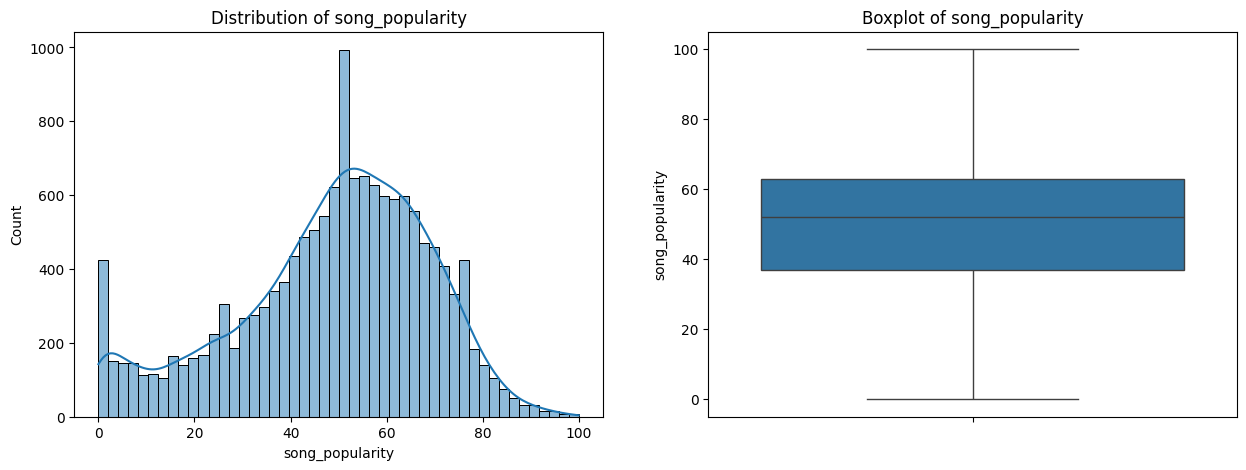

Skewness: -0.5657432335514208
Kurtosis: -0.1645525873452378


In [22]:
target = 'song_popularity'

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.histplot(data[target], kde=True, ax=ax[0])
ax[0].set_title(f'Distribution of {target}')

sns.boxplot(data[target], ax=ax[1])
ax[1].set_title(f'Boxplot of {target}')

plt.show()

print("Skewness:", data[target].skew())
print("Kurtosis:", data[target].kurt())

- The target spans the full range **0 to 100**, so the task has broad coverage.
- Mean is **48.65** and median is **52**, indicating central tendency near mid-popularity.
- Q1 = **37**, Q3 = **63**, so the middle 50% of songs lie in a moderate popularity band.
- Skewness is **-0.566** (slightly left-skewed), which means there are relatively more low-popularity tails than high tails.
- Kurtosis is **-0.165**, suggesting a flatter-than-normal distribution (not heavily peaked).

This target is suitable for regression. Because it is bounded (0-100), report MAE/RMSE along with R2, and inspect residuals for boundary effects.



## Univariate Analysis

In [23]:
num_cols = data.select_dtypes(include=['int','float']).columns.tolist()
num_cols = [c for c in num_cols if c != "song_popularity"]
num_cols

['song_duration_ms',
 'acousticness',
 'danceability',
 'energy',
 'instrumentalness',
 'key',
 'liveness',
 'loudness',
 'audio_mode',
 'speechiness',
 'tempo',
 'time_signature',
 'audio_valence']

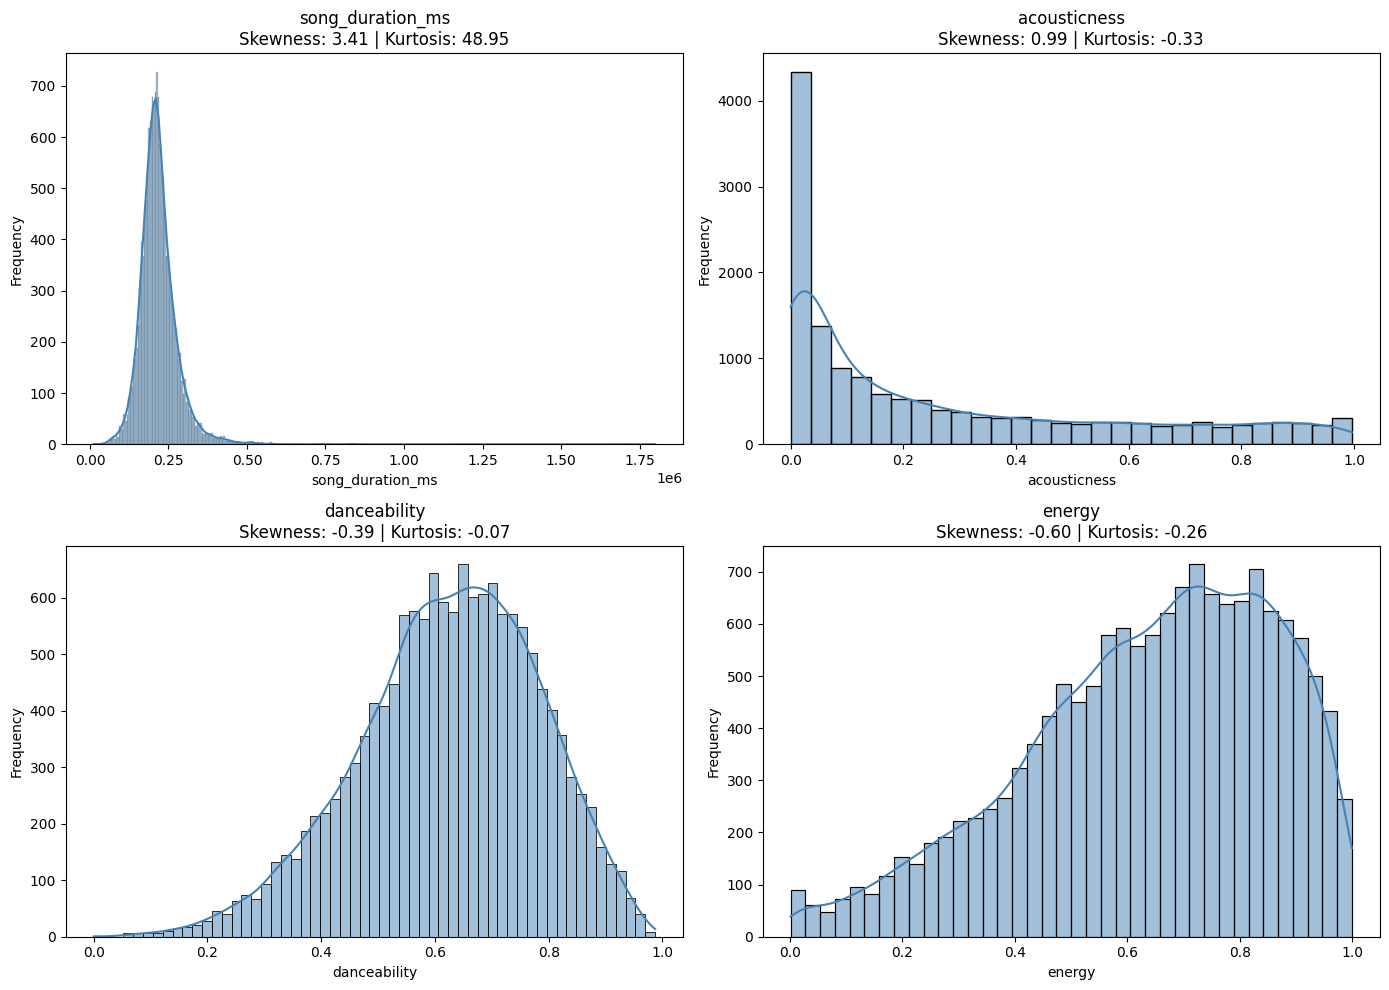

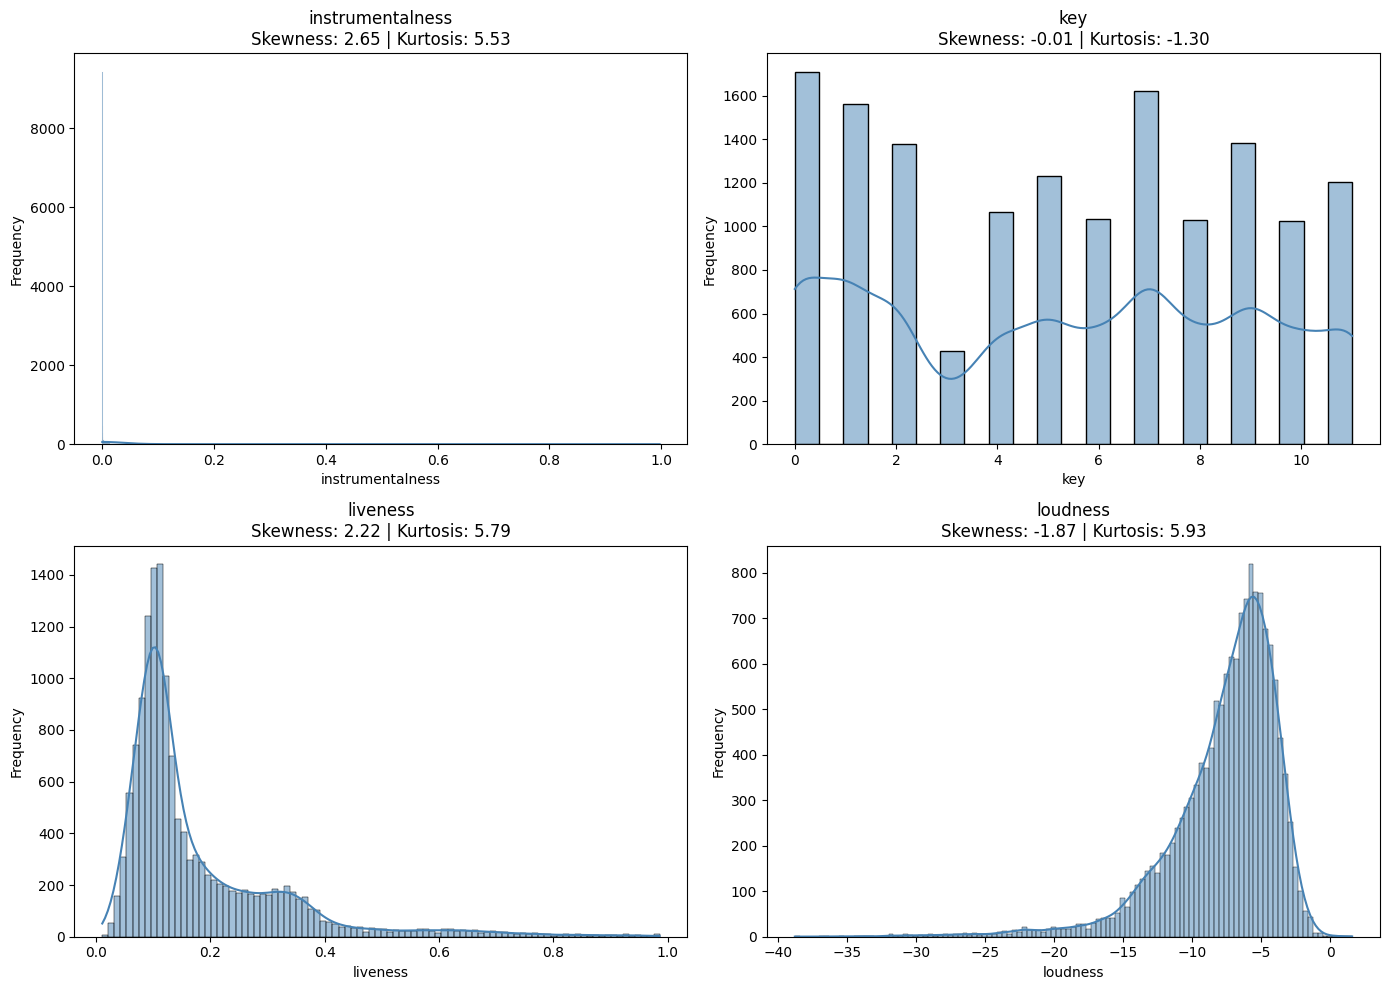

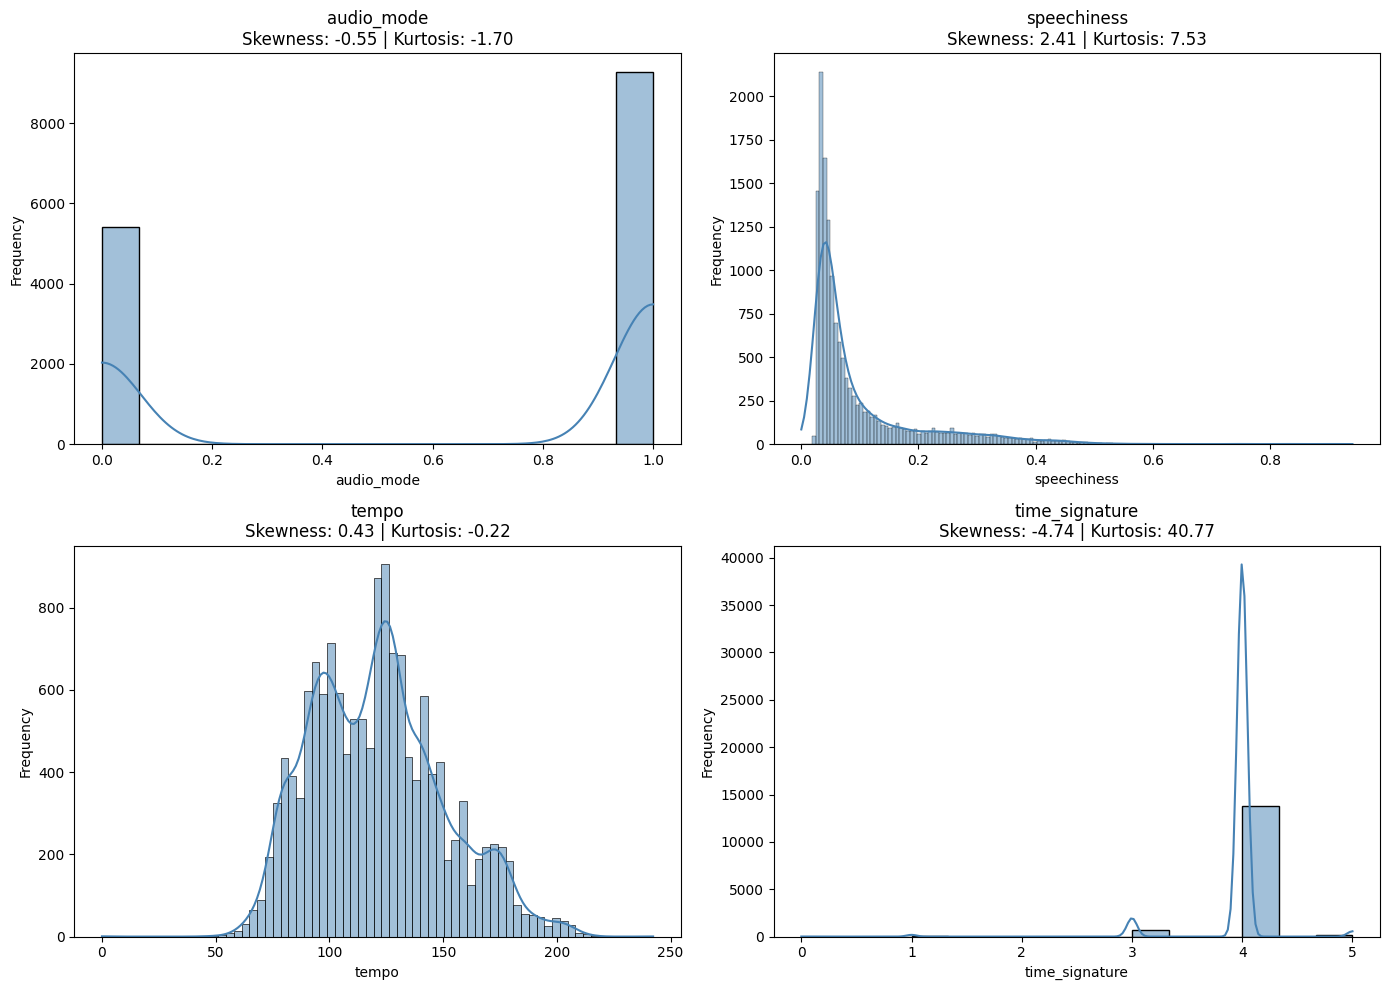

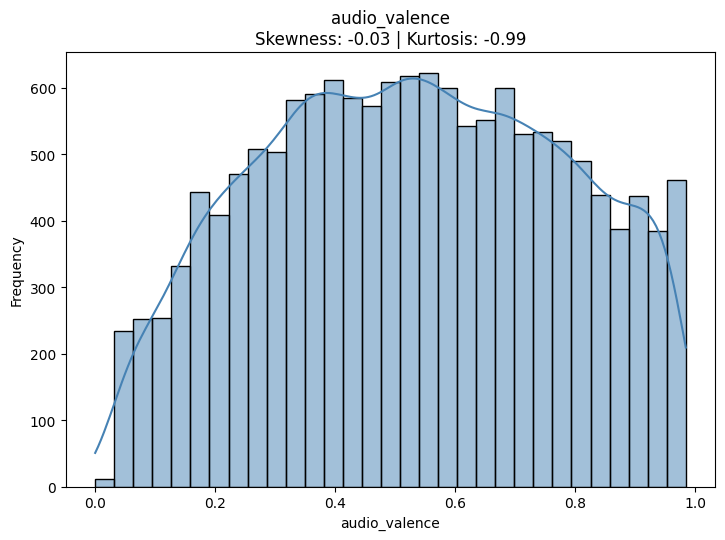

In [24]:
cols_per_fig = 4  # 2x2 grid

for i in range(0, len(num_cols), cols_per_fig):

    subset = num_cols[i:i+cols_per_fig]

    fig, axes = plt.subplots(2, 2, figsize=(14,10))
    axes = axes.flatten()

    for ax, col in zip(axes, subset):

        sns.histplot(data[col], kde=True, ax=ax, color='steelblue')

        skew = data[col].skew()
        kurt = data[col].kurt()

        ax.set_title(f"{col}\nSkewness: {skew:.2f} | Kurtosis: {kurt:.2f}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    # Remove empty subplot if columns < 4
    for j in range(len(subset), 4):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

`song_duration_ms`

The distribution is highly right-skewed, indicating that most songs have a typical duration around 3–4 minutes, while a few songs are extremely long. The high kurtosis suggests the presence of significant outliers, such as extended mixes or live recordings.

---

`acousticness`

Acousticness shows a right-skewed distribution, meaning most songs have low acoustic content. This suggests that the dataset is dominated by electronically produced or studio-recorded music.

---

`danceability`

Danceability is approximately normally distributed with most songs ranging between 0.5 and 0.8. This indicates that many songs in the dataset are moderately to highly suitable for dancing.

---

`energy`

Energy is slightly left-skewed, showing that a large number of songs have high energy levels, which is common in modern genres such as pop, electronic, and rock.

---

`instrumentalness`

Instrumentalness is heavily right-skewed, with most values close to 0, indicating that the majority of songs contain vocals, while purely instrumental tracks are rare.

---

`key`

The musical key appears evenly distributed, suggesting that songs are spread across different keys without a strong bias toward any specific one.

---

`liveness`

Liveness is right-skewed, indicating that most songs are studio recordings, while only a small portion represent live performances.

---

`loudness`

Loudness is left-skewed, meaning most songs are relatively loud and fall within the typical mastering range used in modern music production.

---

`audio_mode`

Audio mode is a binary feature, and the distribution shows that major mode songs are more common than minor mode songs in the dataset.

---

`speechiness`

Speechiness is highly right-skewed, indicating that most songs contain minimal spoken content. Higher values generally correspond to rap or spoken-word segments.

---

`tempo`

Tempo is approximately normally distributed, with most songs ranging between 100 and 140 BPM, which is typical for popular music.

---

`time_signature`

Time signature is highly concentrated around 4, meaning most songs follow the 4/4 rhythm pattern, the most common time signature in modern music.

---

`audio_valence`

Valence is symmetrically distributed, suggesting that the dataset contains a balanced mix of positive (happy) and negative (sad) sounding songs.

## Outlier Analysis by IQR Method

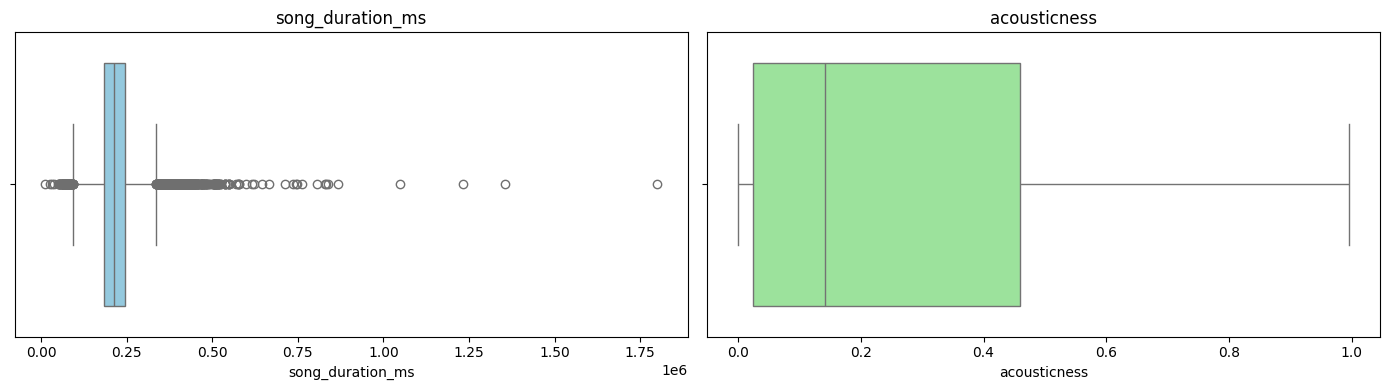

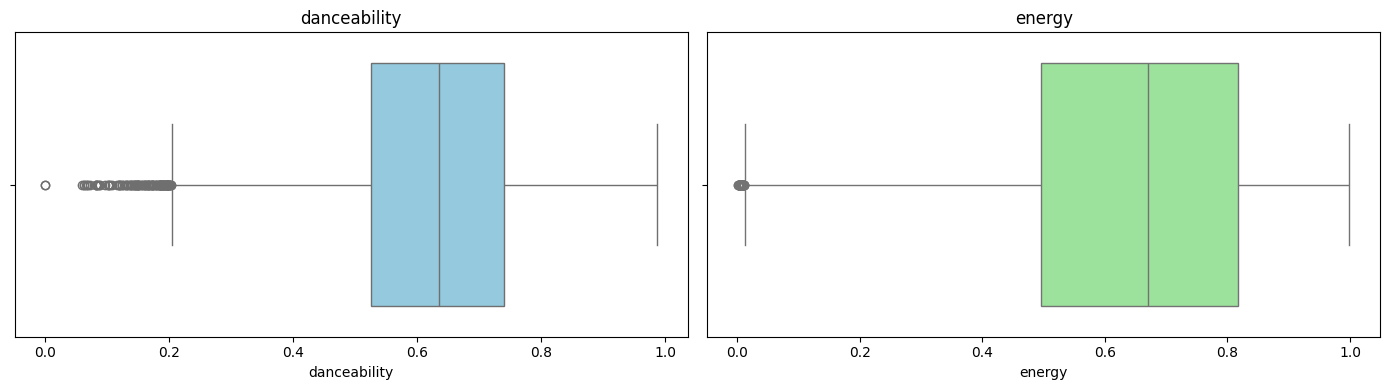

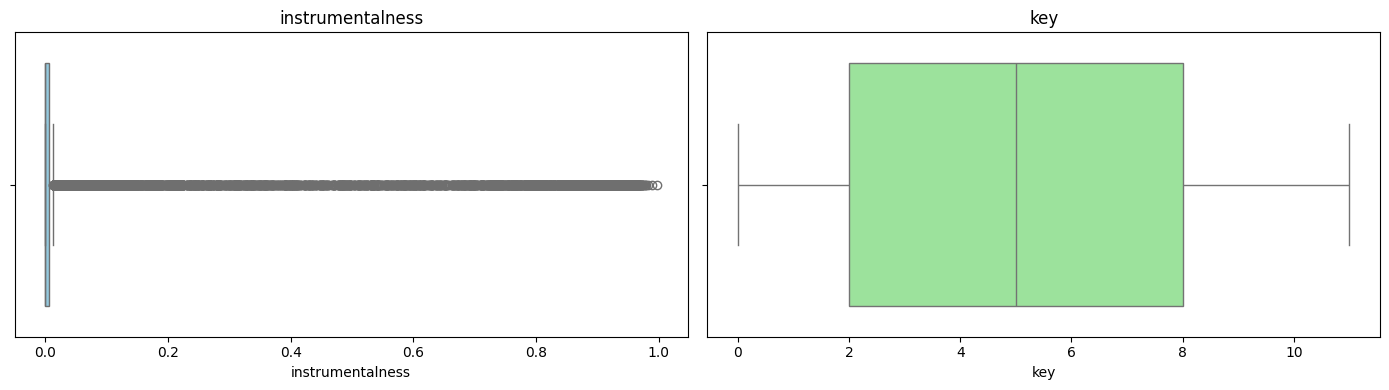

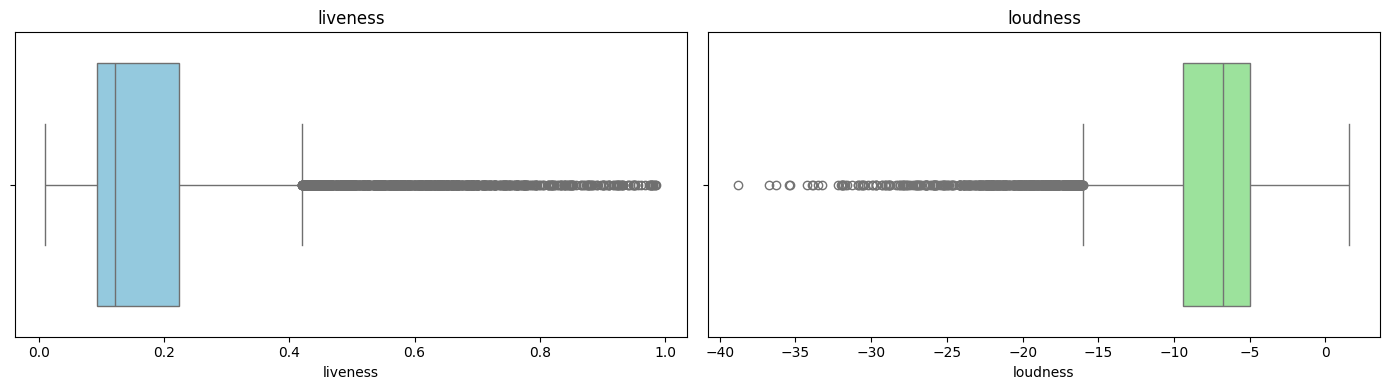

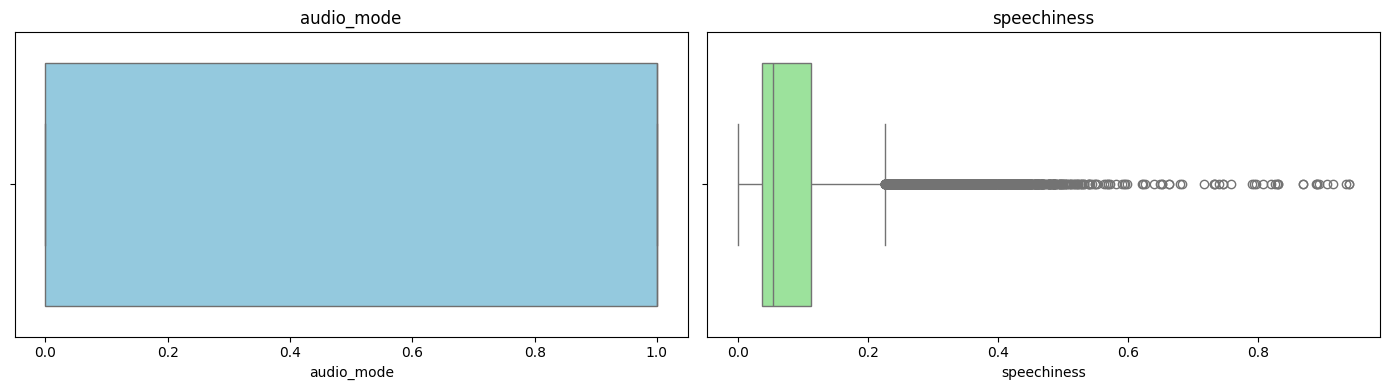

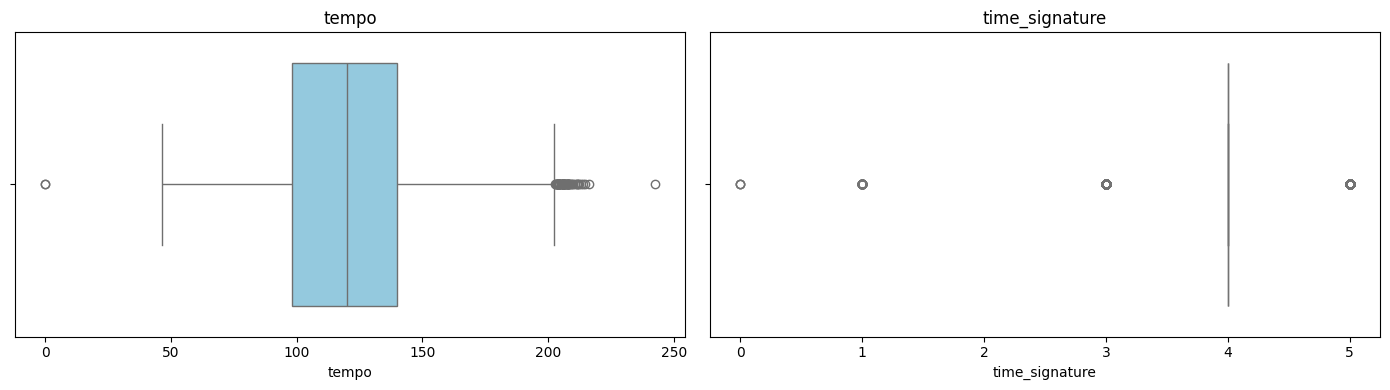

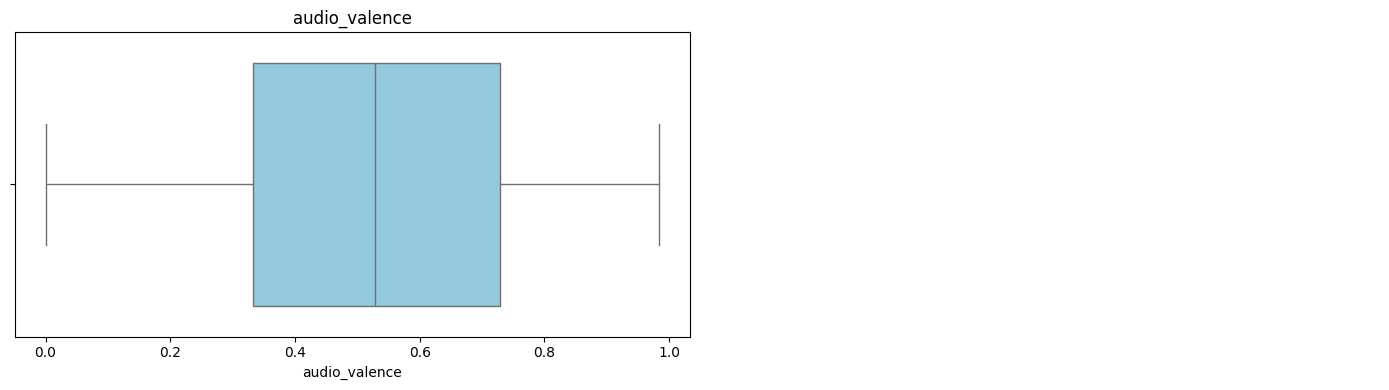

In [25]:
cols = data[num_cols].columns.tolist()

# Loop in steps of 2 columns
for i in range(0, len(cols), 2):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    # Left plot
    col1 = cols[i]
    sns.boxplot(x=data[col1], ax=ax[0], color="skyblue")
    ax[0].set_title(f"{col1}")
    ax[0].set_xlabel(col1)

    # Right plot (only if exists)
    if i + 1 < len(cols):
        col2 = cols[i + 1]
        sns.boxplot(x=data[col2], ax=ax[1], color="lightgreen")
        ax[1].set_title(f"{col2}")
        ax[1].set_xlabel(col2)
    else:
        ax[1].axis("off")  # hide empty subplot if odd number of columns
    plt.tight_layout()
    plt.show()

In [26]:
def iqr_method(series):
  q1, q3 = series.quantile(0.25), series.quantile(0.75)
  iqr = q3 - q1
  lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  return ((series < lower) | (series > upper)).sum()

outlier_counts = {col: iqr_method(data[col]) for col in num_cols}
outlier_df = pd.DataFrame({"feature": outlier_counts.keys(), "outlier_count": outlier_counts.values()})
outlier_df["outlier_pct"] = (outlier_df["outlier_count"] / len(data) * 100).round(2)
outlier_df.sort_values("outlier_pct", ascending=False)

,feature,outlier_count,outlier_pct
4,instrumentalness,3151,21.46
9,speechiness,1801,12.27
11,time_signature,939,6.40
6,liveness,923,6.29
0,song_duration_ms,630,4.29
7,loudness,559,3.81
2,danceability,113,0.77
10,tempo,68,0.46
3,energy,42,0.29
1,acousticness,0,0.00


### Key Observations

1. `instrumentalness` (21.46%) has the highest proportion of outliers. This occurs because most songs have instrumentalness values close to 0, indicating the presence of vocals, while a smaller number of purely instrumental tracks have values close to 1, creating a highly skewed distribution.

2. `speechiness` (12.27%) also shows a notable percentage of outliers. This is expected since most songs contain minimal spoken content, while some genres such as rap or spoken-word music have much higher speechiness values.

3. `time_signature` (6.40%) appears to have outliers mainly because the majority of songs follow the 4/4 time signature, while other rhythmic patterns are relatively uncommon.

4. `liveness` (6.29%) contains moderate outliers, representing songs recorded in live performance environments, which are less common compared to studio recordings.

5. `song_duration_ms` (4.29%) shows some high-end outliers corresponding to extended tracks, live versions, or remixes that are longer than typical song durations.

6. `loudness` (3.81%) includes several extreme values, indicating songs that are either unusually quiet or louder compared to the standard mastering levels.

Features such as `danceability`, `tempo`, and `energy` show very few outliers, suggesting that most songs follow relatively similar patterns in terms of rhythm and intensity.

`acousticness`, `key`, `audio_mode`, and `audio_valence` show no significant outliers, indicating that their distributions are relatively stable within the dataset.


Overall, the observed outliers appear to be the result of natural variability in musical characteristics rather than data quality issues. These values may represent unique song attributes such as instrumental compositions, live recordings, or genre-specific styles. Therefore, instead of removing them outright, they will be considered carefully during the modeling phase, as they may contain useful information for predicting song_popularity.

## Bivariate Analysis vs Target

In [27]:
corr_pearson = data[num_cols + ['song_popularity']].corr(method="pearson")['song_popularity'].sort_values(ascending=False)
corr_spearman = data[num_cols + ['song_popularity']].corr(method="spearman")['song_popularity'].sort_values(ascending=False)

pd.DataFrame({
    "pearson_with_target": corr_pearson,
    "spearman_with_target": corr_spearman
}).sort_values("pearson_with_target", ascending=False)

,pearson_with_target,spearman_with_target
song_popularity,1.000000,1.000000
danceability,0.055485,0.049525
loudness,0.051103,0.095616
time_signature,0.023435,0.026065
audio_mode,0.009361,0.009230
speechiness,-0.001585,0.005970
key,-0.002981,-0.004273
song_duration_ms,-0.006971,0.033180
energy,-0.016610,-0.004235
tempo,-0.028109,-0.027524


Top absolute linear correlations with `song_popularity` are relatively weak:
- `instrumentalness`: **-0.092**
- `danceability`: **+0.055**
- `loudness`: **+0.051**
- `audio_valence`: **-0.045**
- `liveness`: **-0.037**
- `acousticness`: **-0.032**

- No single audio feature strongly explains popularity.
- This suggests popularity is influenced by multiple weak factors and likely nonlinear interactions.
- Linear models can still be useful as a baseline, but expectations for very high R2 should be moderate.

### Top 6 Features vs `song_popularity`

In [28]:
top_feats = corr_pearson.drop("song_popularity").abs().sort_values(ascending=False).head(6).index.tolist()
top_feats

['instrumentalness',
 'danceability',
 'loudness',
 'audio_valence',
 'liveness',
 'acousticness']

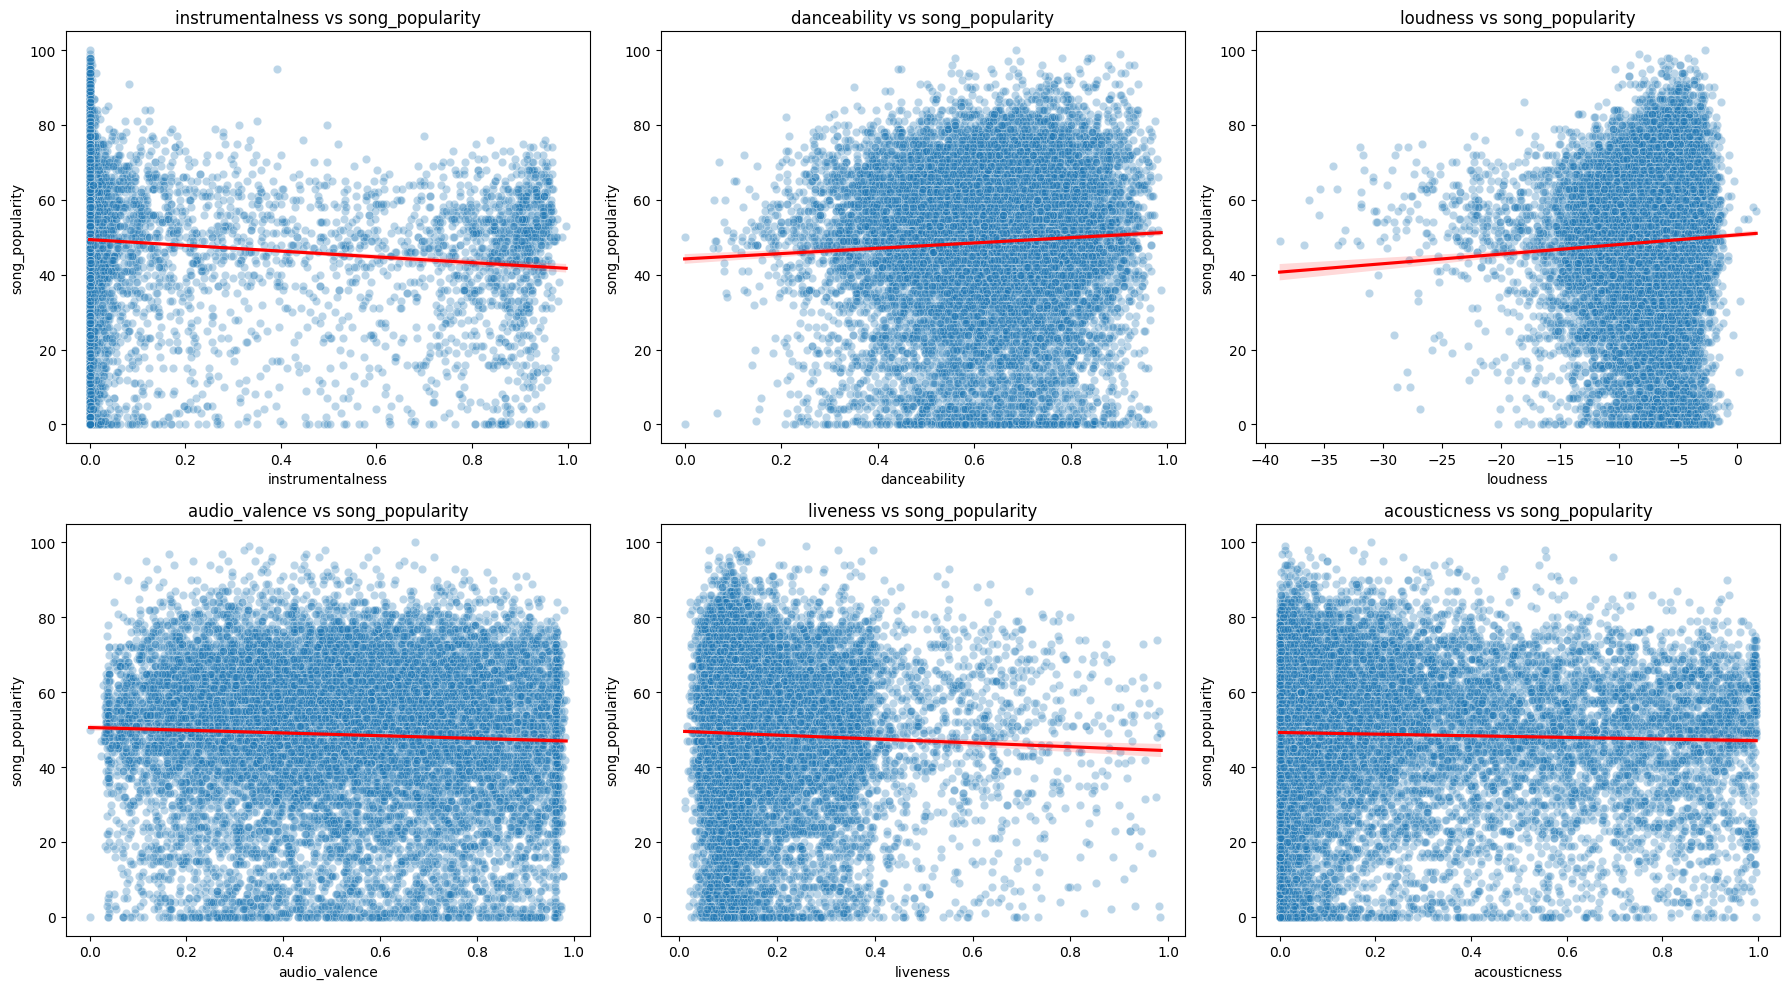

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))
axes = axes.flatten()
for i, col in enumerate(top_feats):
  sns.scatterplot(data=data, x=col, y="song_popularity", alpha=0.3, ax=axes[i])
  sns.regplot(data=data, x=col, y="song_popularity", scatter=False, color="red", ax=axes[i])
  axes[i].set_title(f"{col} vs song_popularity")
plt.tight_layout()
plt.show()

`instrumentalness` vs `song_popularity`

The plot shows a slight negative relationship between instrumentalness and song_popularity. Most songs with higher popularity tend to have lower instrumentalness values, indicating that songs with vocals are generally more popular than purely instrumental tracks.

---

`danceability` vs `song_popularity`

Danceability shows a mild positive relationship with song_popularity. Songs with higher danceability scores tend to have slightly higher popularity, suggesting that tracks that are easier to dance to may appeal more to listeners.

---

`loudness` vs `song_popularity`

Loudness demonstrates a positive trend with song_popularity. Songs that are louder (closer to 0 dB) appear to have slightly higher popularity levels, which aligns with modern music production trends where louder tracks are often perceived as more energetic.

---

`audio_valence` vs `song_popularity`

The relationship between valence and popularity appears weak, with the regression line nearly flat. This suggests that whether a song sounds happy or sad does not strongly influence its popularity.

---

`liveness` vs `song_popularity`

Liveness shows a slight negative trend, indicating that songs recorded in live environments may be slightly less popular compared to studio-recorded tracks. However, the relationship is relatively weak.

---

`acousticness` vs `song_popularity`

Acousticness displays very little correlation with popularity, as the data points are widely scattered and the regression line is nearly flat. This suggests that the acoustic nature of a song alone may not significantly determine its popularity.

---

From the visual analysis, most features show weak to moderate relationships with song_popularity, indicating that popularity is influenced by multiple factors rather than a single audio attribute. Among the analyzed features, danceability and loudness show slightly stronger positive trends, while instrumentalness and liveness show weak negative relationships with popularity.

## Multivariate Analysis

### Correlation + Multicollinearity Check


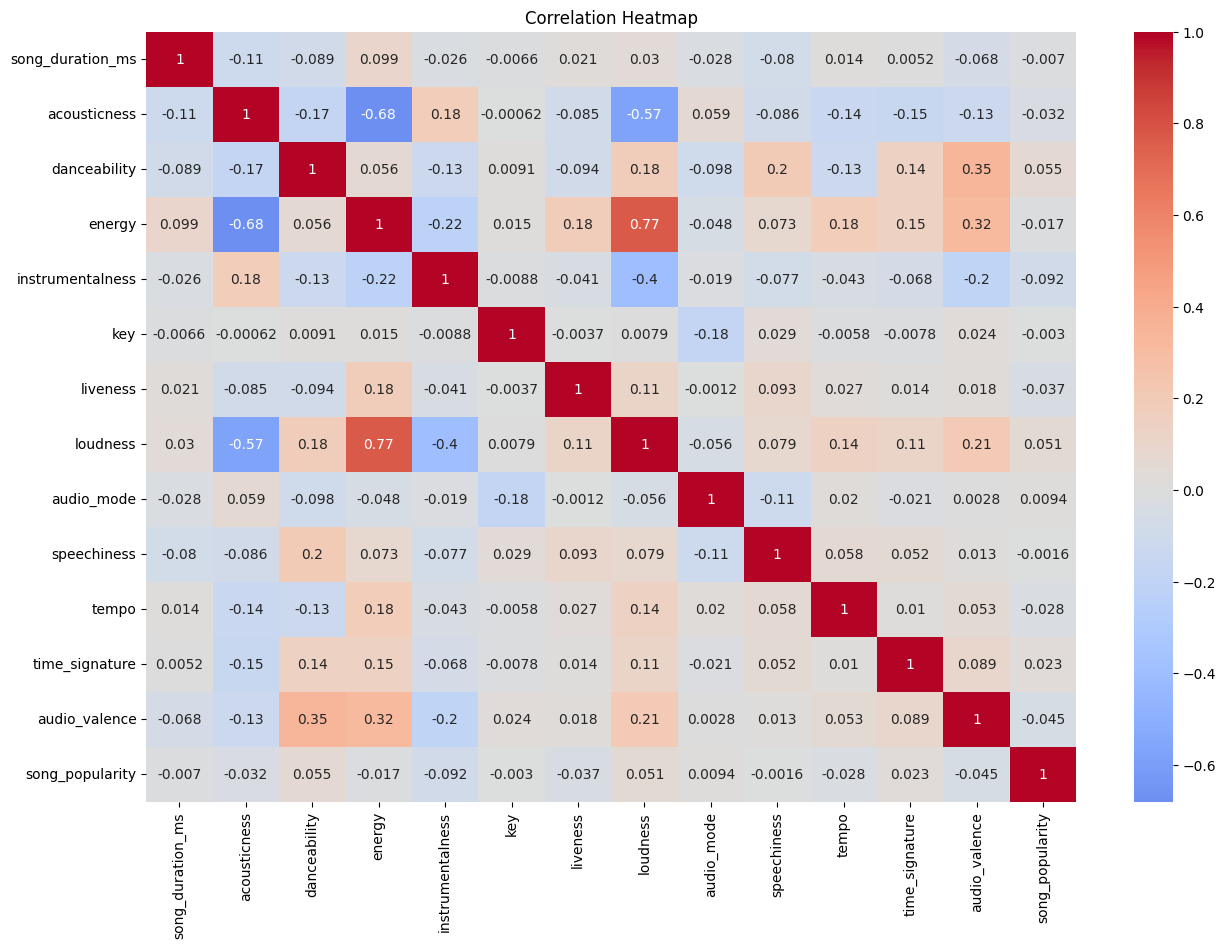

In [30]:
plt.figure(figsize=(15, 10))
sns.heatmap(data[num_cols + ["song_popularity"]].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Relationship with `song_popularity`

- The correlation values between features and song_popularity are relatively small, indicating weak linear relationships. This suggests that song popularity is likely influenced by multiple factors rather than a single audio feature.

- Some observations include:

  - `danceability` (0.055) and `loudness` (0.051) show a slight positive relationship with popularity.

  - `instrumentalness` (-0.092) shows a weak negative relationship, suggesting songs with vocals tend to be slightly more popular.

  - `audio_valence` (-0.045) and `liveness` (-0.037) also show weak negative correlations with popularity.

  - Most other features have correlations close to zero, indicating minimal direct influence.

---

Correlation Between Features

- Some stronger relationships between independent variables are observed:

  - `energy` and `loudness` (0.77) show a strong positive correlation, which is expected since louder songs are typically more energetic.

  - `acousticness` and `energy` (-0.68) show a strong negative relationship, meaning highly acoustic songs tend to have lower energy.

  - `danceability` and `audio_valence` (0.35) show a moderate positive relationship, suggesting happier songs tend to be more danceable.

  - `energy` and `audio_valence` (0.32) also show a moderate positive relationship.

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(data[num_cols])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,Feature,VIF
0,const,287.406770
4,energy,3.882547
8,loudness,3.023055
2,acousticness,2.045578
3,danceability,1.423589
13,audio_valence,1.414588
5,instrumentalness,1.264329
10,speechiness,1.094279
11,tempo,1.071618
9,audio_mode,1.059212


- `energy` (3.88) and `loudness` (3.02) have the highest VIF values among the predictors. This indicates a moderate level of correlation, which is expected because louder songs generally have higher energy.

- `acousticness` (2.05) also shows mild correlation with other variables but remains within an acceptable range.

- The remaining features such as `danceability, audio_valence, instrumentalness, speechiness, tempo, audio_mode, liveness, song_duration_ms, time_signature`, and `key` all have VIF values close to 1, indicating very low multicollinearity.

Overall, the dataset shows no severe multicollinearity issues, as all predictor variables have VIF values well below the critical threshold of 5.

## Categorical-like Numerical Features

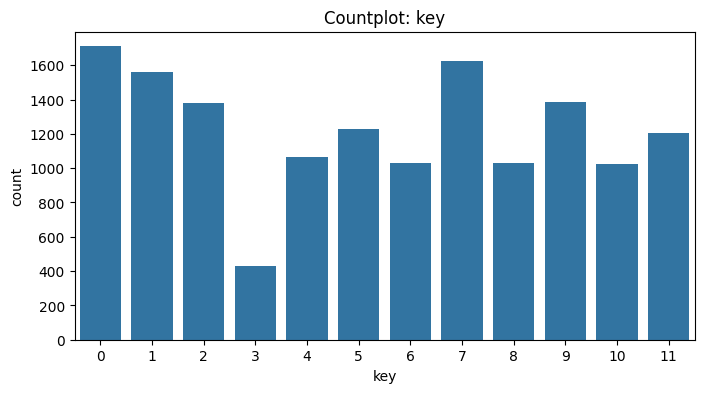

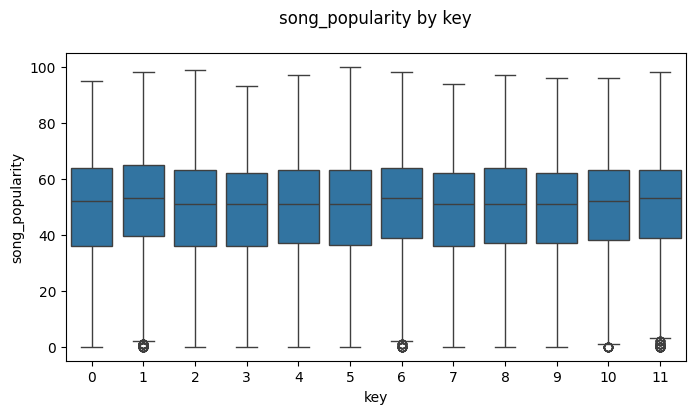

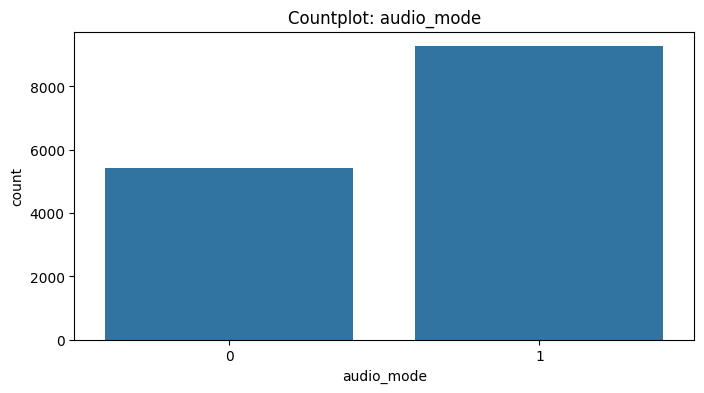

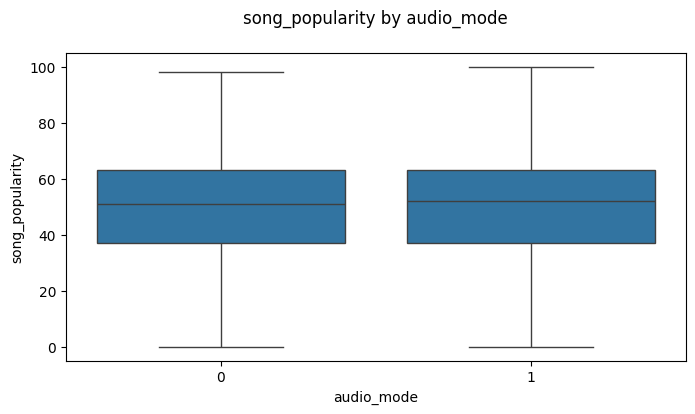

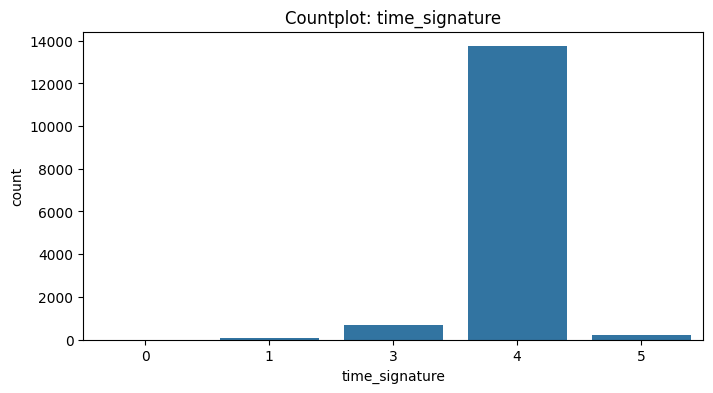

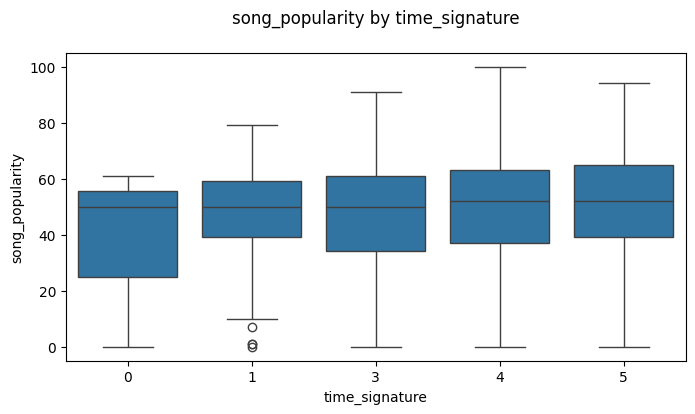

In [32]:
cat_like = [c for c in ["key", "audio_mode", "time_signature"] if c in data.columns]
for c in cat_like:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=c, order=sorted(data[c].dropna().unique()))
    plt.title(f"Countplot: {c}")
    plt.show()
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=data, x=c, y="song_popularity")
    plt.title(f"song_popularity by {c}\n")
    plt.show()

1. `key`

Distribution:

The countplot shows that songs are fairly distributed across different musical keys, although some keys appear slightly more frequently than others.

Popularity by Key:

The boxplot indicates that the median popularity is relatively similar across all keys, with only minor variations. This suggests that the musical key of a song does not significantly impact song popularity.

---

2. `audio_mode`

Distribution:

The countplot shows that audio_mode = 1 (major mode) appears more frequently than audio_mode = 0 (minor mode). This indicates that most songs in the dataset are composed in a major scale, which is generally associated with brighter and more positive sounds.

Popularity by Audio Mode:

The boxplot shows that the distribution of song_popularity for both modes is quite similar. Although major mode songs appear slightly more common, the difference in popularity between major and minor modes is not substantial.

---

3. `time_signature`

Distribution:

The countplot reveals that the majority of songs use time_signature = 4, which corresponds to the 4/4 rhythm pattern, the most common time signature in modern music.

Popularity by Time Signature:

The boxplot shows that songs with different time signatures have similar popularity distributions. Although songs with time_signature = 4 dominate the dataset, there is no strong evidence that time signature significantly influences popularity.

# Feature Engineering

In [33]:
df = data.copy()

## Handling Tempo missing values

In [34]:
print("Unique Values:", df['tempo'].unique())
print("Count:", df['tempo'].nunique())

Unique Values: [  0.     84.388 101.644 ... 134.141 186.443  98.162]
Count: 12112


In [35]:
# Tempo=0 is musically invalid in Spotify-like audio features; mark and repair deterministically
df["tempo_was_zero"] = (df["tempo"] <= 0).astype(int)

In [36]:
df.loc[df["tempo"] <= 0, "tempo"] = np.nan

In [37]:
# median is robust to outliers
df["tempo"] = df["tempo"].fillna(df["tempo"].median())

## Duration in minutes

In [38]:
df["song_duration_min"] = df["song_duration_ms"] / 60000

# log1p compresses extreme values while preserving order.
# Linear models often fit better when skewed features are transformed.
df["log_duration"] = np.log1p(df["song_duration_ms"])

## Transforming skewed features

In [39]:
# Skewed positive variables
for c in ["instrumentalness", "speechiness", "liveness", "acousticness"]:
    df[f"log1p_{c}"] = np.log1p(df[c])

## Loudness(dB) to Amplitude ratio

In [40]:
# Loudness is in dB (negative usually): convert to linear-ish signal
# amplitude_ratio ~ 10^(dB/20)
df["loudness_amp"] = 10 ** (df["loudness"] / 20)

## Interactive Features

In [41]:
df["energy_loudness"] = df["energy"] * df["loudness_amp"] #highly positively correlated 0.77
df["valence_energy"] = df["audio_valence"] * df["energy"] #moderately positively correlated 0.32
df["acoustic_vs_energy"] = df["acousticness"] - df["energy"] # highly negatively correlated -0.68
df["dance_valence"] = df["danceability"] * df["audio_valence"]

## Indicator Features

In [42]:
df["high_speech"] = (df["speechiness"] > 0.33).astype(int)
df["live_track"] = (df["liveness"] > 0.8).astype(int)
df["very_instrumental"] = (df["instrumentalness"] > 0.5).astype(int)

## Cyclical Encoding for Musical `key`

To understand cyclical encoding, it helps to stop thinking of the musical keys as a list of numbers and start thinking of them as positions on a clock face.

key : 0-11

Standard machine learning models are "linear." They think 11 is very far from 0 because 11-0 = 11.

We map the 12 keys onto a circle so that Key 11 and Key 0 end up physically next to each other again.

To do this, we use two coordinates: Sine (y-axis) and Cosine (x-axis). Together, they act like GPS coordinates for each key on that circle.

  - Key 0 (C): Sits at the very top of the circle (0,1)

  - Key 6 (F#): Sits at the very bottom (0,-1)

  - Key 11 (B): Sits just to the left of the top, very close to Key 0.

feature_sin = sin(2 * pi * feature_value / period)

feature_cos = cos(2 * pi * feature_value / period)

```
feature_sin = sin(2 * pi * feature_value / period)
feature_cos = cos(2 * pi * feature_value / period)

```



In [43]:
df["key_sin"] = np.sin(2 * np.pi * df["key"] / 12)
df["key_cos"] = np.cos(2 * np.pi * df["key"] / 12)

## Categorical Encoding

### Tempo

In [44]:
df["tempo_category"] = pd.cut(
    df["tempo"],
    bins=[0, 90, 120, 150, 260],
    labels=["slow", "medium", "fast", "very_fast"],
    include_lowest=True
)

### Numerical Categories

In [45]:
cat_cols = ["audio_mode", "time_signature", "tempo_category"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

## Dropping Redundant Columns

In [46]:
drop_cols = ["song_duration_ms", "key","loudness","instrumentalness", "speechiness", "liveness", "acousticness","tempo"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [47]:
df.head(10)

,danceability,energy,audio_valence,song_popularity,tempo_was_zero,song_duration_min,log_duration,log1p_instrumentalness,log1p_speechiness,log1p_liveness,...,key_sin,key_cos,audio_mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,tempo_category_medium,tempo_category_fast,tempo_category_very_fast
0,0.000,0.4930,0.0000,0.0,1,0.200000,9.392745,0.000000,0.000000,0.376380,...,-0.500000,-8.660254e-01,True,False,False,False,False,False,True,False
1,0.365,0.2750,0.0846,37.0,0,0.436433,10.173018,0.672944,0.071204,0.062975,...,-1.000000,-1.836970e-16,True,False,False,True,False,False,False,False
2,0.273,0.8460,0.0326,19.0,0,0.522883,10.353735,0.000000,0.094401,0.662688,...,-0.500000,-8.660254e-01,True,False,False,True,False,True,False,False
3,0.777,0.3760,0.3490,12.0,0,0.598667,10.489077,0.000000,0.584448,0.068219,...,-0.866025,-5.000000e-01,True,False,False,True,False,True,False,False
4,0.581,0.1400,0.2480,61.0,0,0.833567,10.820078,0.670390,0.193921,0.103459,...,0.500000,-8.660254e-01,True,False,False,True,False,False,False,True
5,0.721,0.1750,0.6320,58.0,0,0.841800,10.829907,0.642906,0.069246,0.101654,...,-0.500000,-8.660254e-01,True,False,False,True,False,False,False,False
6,0.708,0.5520,0.6480,40.0,0,0.842883,10.831193,0.659590,0.048981,0.123986,...,0.000000,1.000000e+00,False,False,False,True,False,False,True,False
7,0.809,0.6680,0.1910,13.0,0,0.884433,10.879311,0.000000,0.660624,0.092032,...,0.866025,-5.000000e-01,True,False,True,False,False,True,False,False
8,0.543,0.0370,0.2130,52.0,0,0.908983,10.906690,0.136278,0.038836,0.094310,...,-0.866025,5.000000e-01,True,False,False,True,False,False,False,False
9,0.516,0.0971,0.4600,62.0,0,0.920217,10.918972,0.668342,0.054393,0.102557,...,0.500000,-8.660254e-01,True,False,False,True,False,True,False,False


In [48]:
df.columns

Index(['danceability', 'energy', 'audio_valence', 'song_popularity',
       'tempo_was_zero', 'song_duration_min', 'log_duration',
       'log1p_instrumentalness', 'log1p_speechiness', 'log1p_liveness',
       'log1p_acousticness', 'loudness_amp', 'energy_loudness',
       'valence_energy', 'acoustic_vs_energy', 'dance_valence', 'high_speech',
       'live_track', 'very_instrumental', 'key_sin', 'key_cos', 'audio_mode_1',
       'time_signature_1', 'time_signature_3', 'time_signature_4',
       'time_signature_5', 'tempo_category_medium', 'tempo_category_fast',
       'tempo_category_very_fast'],
      dtype='object')

# Train-Test Split

In [ ]:
target = "song_popularity"
X = df.drop(columns=[target])
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Binary Columns and Continuous Columns

In [50]:
# Detect binary columns automatically (0/1 only)
binary_cols = [
    c for c in X_train.columns
    if set(np.unique(X_train[c].dropna())).issubset({0, 1})
]
# Remaining columns treated as continuous numeric
num_cols = [c for c in X_train.columns if c not in binary_cols]
print("Continuous columns:", len(num_cols))
print("Binary/dummy columns:", len(binary_cols))

Continuous columns: 16
Binary/dummy columns: 12


# Feature Scaling on Continuous Columns

In [ ]:
scaler = StandardScaler()
# Fit only on train continuous columns

X_train_num_scaled = scaler.fit_transform(X_train[num_cols])
X_test_num_scaled = scaler.transform(X_test[num_cols])

In [53]:
# Convert back to DataFrame
X_train_num_scaled = pd.DataFrame(
    X_train_num_scaled, columns=num_cols, index=X_train.index
)
X_test_num_scaled = pd.DataFrame(
    X_test_num_scaled, columns=num_cols, index=X_test.index
)

In [54]:
X_train_scaled = pd.concat([X_train_num_scaled, X_train[binary_cols]], axis=1)
X_test_scaled = pd.concat([X_test_num_scaled, X_test[binary_cols]], axis=1)

In [55]:
# Keep same column order as original X
X_train_scaled = X_train_scaled[X_train.columns]
X_test_scaled = X_test_scaled[X_test.columns]
X_train_scaled.head()

,danceability,energy,audio_valence,tempo_was_zero,song_duration_min,log_duration,log1p_instrumentalness,log1p_speechiness,log1p_liveness,log1p_acousticness,...,key_sin,key_cos,audio_mode_1,time_signature_1,time_signature_3,time_signature_4,time_signature_5,tempo_category_medium,tempo_category_fast,tempo_category_very_fast
8649,1.599193,-0.870805,1.120785,0,0.031105,0.166533,-0.400245,-0.339611,-0.441538,0.883108,...,-0.686978,1.099879,False,False,False,True,False,False,True,False
7369,-0.294926,-1.919591,-0.849834,0,-0.117277,0.004460,-0.400281,-0.741355,-0.449639,-0.629256,...,0.060431,1.280833,True,False,False,True,False,False,False,False
4220,0.614251,1.177254,1.758814,0,-0.487190,-0.432890,-0.400281,0.109507,-0.852346,-0.501067,...,-0.686978,1.099879,False,False,False,True,False,False,True,False
10565,0.923624,1.019711,1.189434,0,0.314657,0.458072,-0.400281,0.236232,-0.862520,-0.041484,...,-0.686978,1.099879,False,False,False,True,False,True,False,False
9939,0.759467,-0.789783,-0.930597,0,0.211714,0.354823,1.545691,-0.137275,0.495997,-0.961419,...,1.354981,-0.745155,False,False,False,True,False,False,True,False


# Quick sanity check

In [56]:
check = pd.DataFrame({
    "mean": X_train_scaled[num_cols].mean(),
    "std": X_train_scaled[num_cols].std()
})
check.describe()

,mean,std
count,1.600000e+01,1.600000e+01
mean,-3.920097e-16,1.000043e+00
std,1.873995e-15,1.403362e-14
min,-7.349858e-15,1.000043e+00
25%,-7.033429e-18,1.000043e+00
50%,2.397416e-17,1.000043e+00
75%,5.059531e-17,1.000043e+00
max,9.120770e-16,1.000043e+00


# Model Training

## Regression Metrics

In [58]:
def regression_metrics(y_true, y_pred):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
  return mae, rmse, r2

results=[]

In [63]:
def plot_model_diagnostics(y_test, y_pred):
    y_test = pd.Series(y_test).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    residuals = y_test - y_pred
    idx = np.arange(len(y_test))
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # 1. Actual vs Prediction by observation index
    axes[0].scatter(idx, y_test, color='tab:blue', alpha=0.6, s=18, label='Actual')
    axes[0].scatter(idx, y_pred, color='tab:orange', alpha=0.6, s=18, label='Prediction')
    axes[0].set_title("Actual vs Prediction")
    axes[0].set_xlabel("Observation Index")
    axes[0].set_ylabel("Song Popularity")
    axes[0].legend()

    # 2. Actual vs Predicted scatter
    axes[1].scatter(y_test, y_pred, color='purple', alpha=0.5, s=20)
    line_min = np.min([y_test.min(), y_pred.min()])
    line_max = np.max([y_test.max(), y_pred.max()])
    axes[1].plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
    axes[1].set_title("Actual vs Predicted Scatter")
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predicted")

    # 3. Density plot of residuals
    sns.kdeplot(residuals, fill=True, color='teal', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[2].set_title("Density Plot of Error Terms")
    axes[2].set_xlabel("Residuals (Actual - Predicted)")
    axes[2].set_ylabel("Density")
    plt.tight_layout()
    plt.show()

## Multiple Linear Regression

In [61]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)

LinearRegression()

Multiple Linear Regression
R2 Score : 0.017895367797275963
RMSE     : 19.963044716741223
MAE      : 15.889704202369787


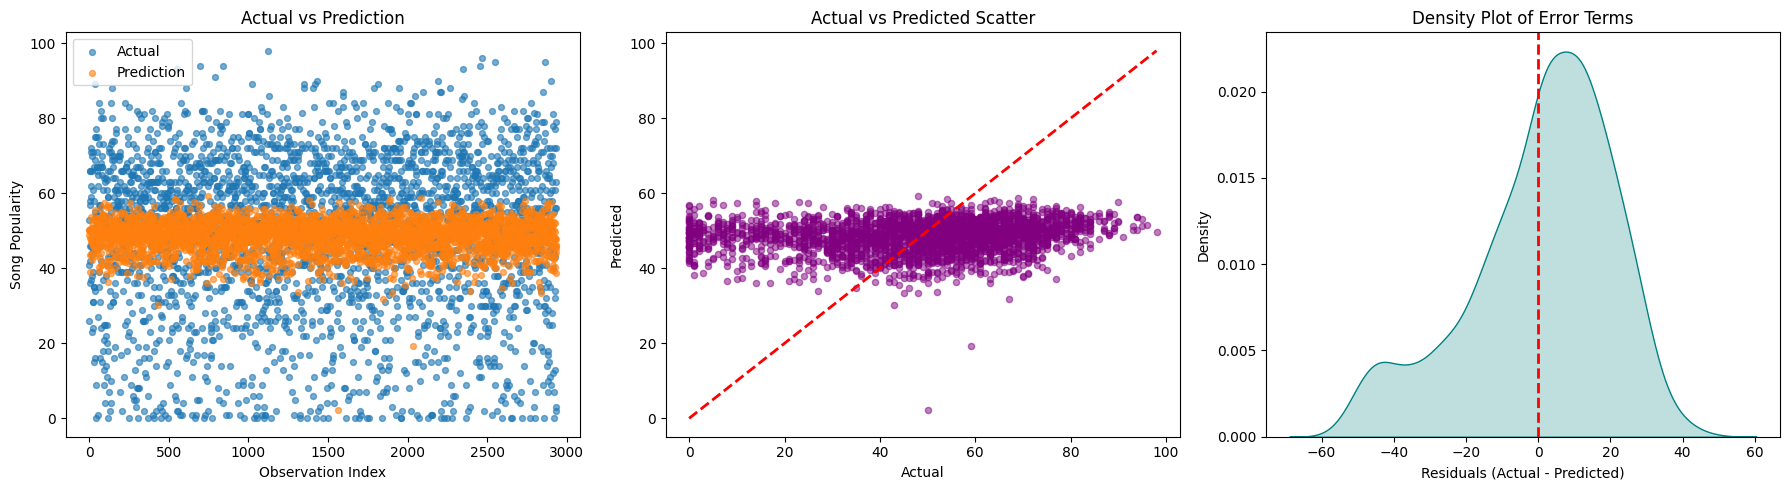

In [64]:
y_pred_test = linear.predict(X_test_scaled)

mae_test, rmse_test, r2_test = regression_metrics(y_test, y_pred_test)
print("Multiple Linear Regression")
print("R2 Score :", r2_test)
print("RMSE     :", rmse_test)
print("MAE      :", mae_test)

plot_model_diagnostics(y_test, y_pred_test)

Actual vs Prediction by Observation Index

- The actual values vary widely across observations, but the predicted values are compressed into a narrow band around the mean. This indicates that the multiple linear regression model is underfitting and is not able to capture the full variability in song popularity.

---

Actual vs Predicted Scatter Plot

- The actual vs predicted scatter plot does not align closely with the 45-degree reference line. Instead, predictions are concentrated in a narrow horizontal range, indicating that the model tends to predict near the average popularity and fails to capture the true spread of the target variable.

---

Density Plot of Error Terms

- The residual density plot is widely spread rather than tightly centered around zero, indicating that prediction errors are substantial. The slight shift toward positive residuals suggests that the model tends to underpredict song popularity in many cases. This further confirms that the linear regression model is not capturing the target well.

In [65]:
results.append({
"Model": "Multiple Linear Regression",
"MAE": mae_test,
"RMSE": rmse_test,
"R2": r2_test
})

## Ridge Regression (L2 Regularization)

In [66]:
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100])
ridge_cv.fit(X_train_scaled, y_train)

RidgeCV(alphas=[0.01, 0.1, 1, 10, 50, 100])

In [67]:
y_pred = ridge_cv.predict(X_test_scaled)

mae_test, rmse_test, r2_test = regression_metrics(y_test, y_pred)
print("Ridge Regression")
print("R2 Score :", r2_test)
print("RMSE     :", rmse_test)
print("MAE      :", mae_test)

Ridge Regression
R2 Score : 0.01913062865159265
RMSE     : 19.950486316264595
MAE      : 15.88251119860112


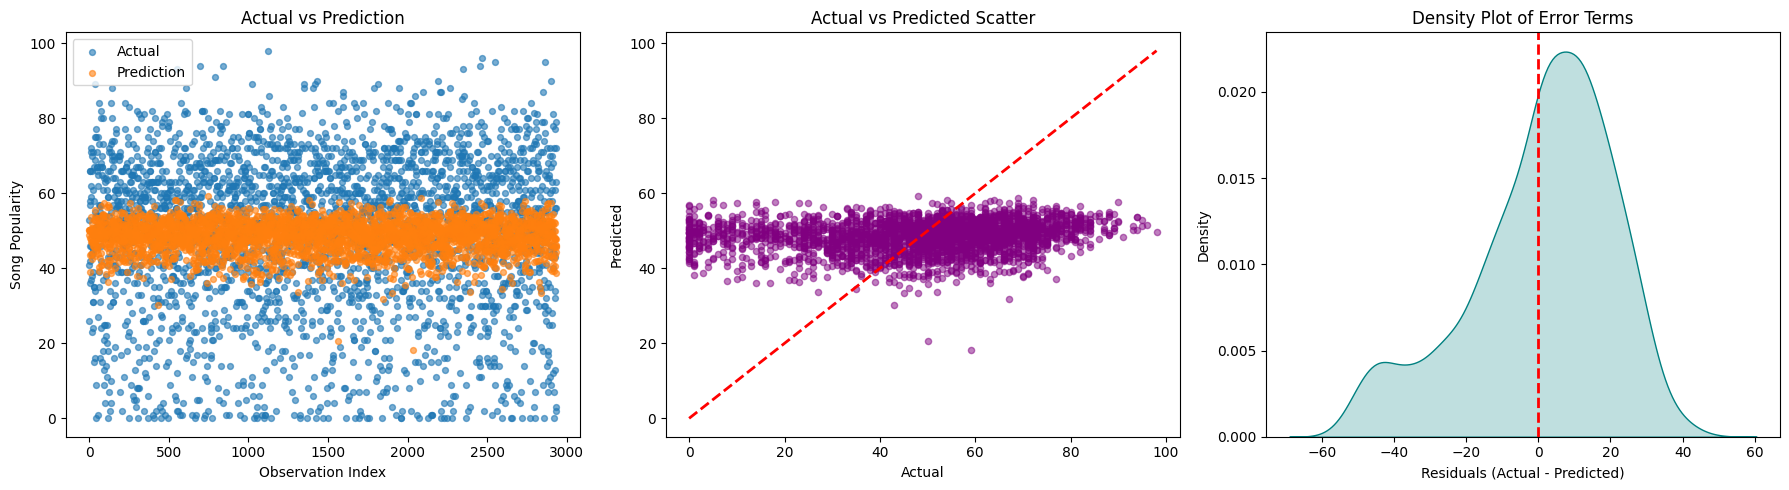

In [68]:
plot_model_diagnostics(y_test, y_pred)

In [69]:
results.append({
"Model": "Ridge Regression",
"MAE": mae_test,
"RMSE": rmse_test,
"R2": r2_test,
"Best_Alpha": ridge_cv.alpha_
})

Ridge Regression performed slightly better than Multiple Linear Regression, as seen in the small increase in R2 and slight reduction in RMSE and MAE. However, the improvement was minimal. The diagnostic plots show that predictions are still concentrated around the mean, indicating that the model continues to underfit the data and does not capture the full variability in song popularity.

## Lasso Regression (L1 Regularization)

In [70]:
lasso_cv = LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], cv=5, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], cv=5, max_iter=10000)

In [71]:
y_pred = lasso_cv.predict(X_test_scaled)

mae_test, rmse_test, r2_test = regression_metrics(y_test, y_pred)
print("Lasso Regression")
print("R2 Score :", r2_test)
print("RMSE     :", rmse_test)
print("MAE      :", mae_test)

Lasso Regression
R2 Score : 0.018876737714268566
RMSE     : 19.953068168693466
MAE      : 15.883937150749148


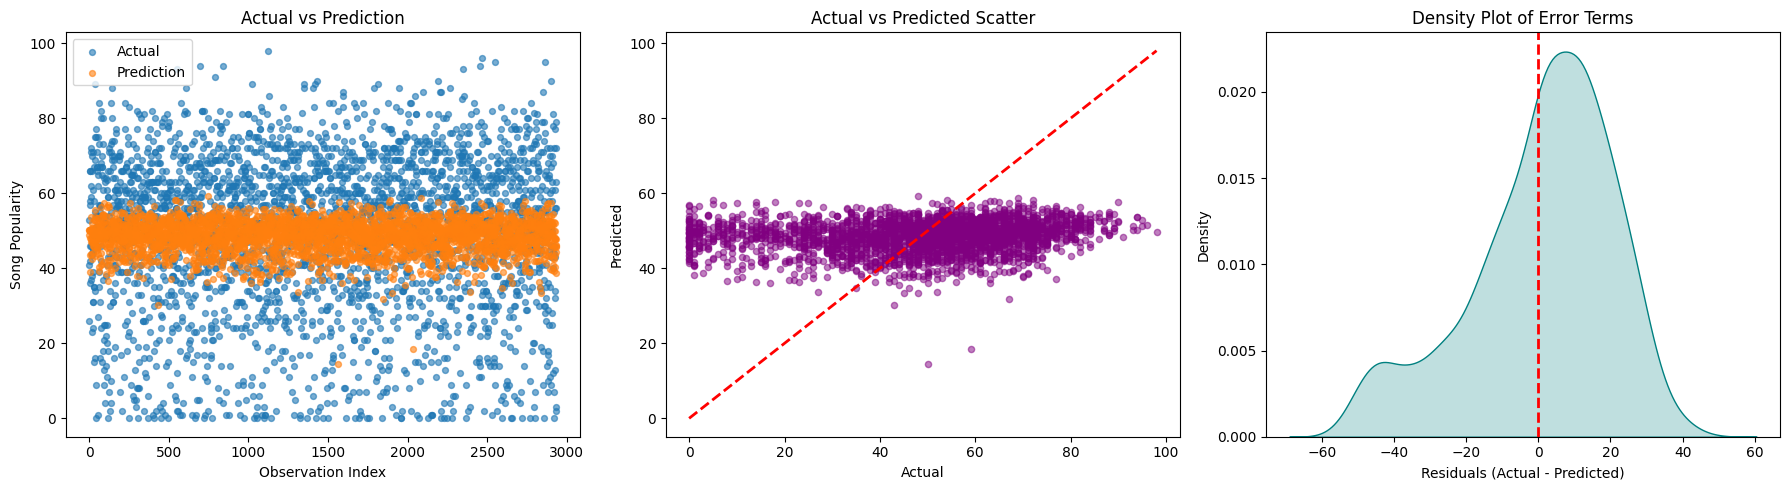

In [72]:
plot_model_diagnostics(y_test, y_pred)

In [73]:
results.append({
"Model": "Lasso Regression",
"MAE": mae_test,
"RMSE": rmse_test,
"R2": r2_test,
"Best_Alpha": lasso_cv.alpha_
})

Lasso Regression produced a slight improvement over Multiple Linear Regression, but its performance remained very close to Ridge Regression and only marginally better than the baseline.

The diagnostic plots were almost identical to those of Ridge, showing that predictions were still concentrated around the mean and that the model continued to underfit the data. This suggests that although Lasso helped by applying regularization and possible feature selection, the dataset does not appear to benefit strongly from sparse coefficient selection.

Instead, the available audio features likely contain only weak predictive signal for song popularity.

## ElasticNet Regression

In [74]:
elasticnet_cv = ElasticNetCV(
    l1_ratio=[0.2, 0.4, 0.6, 0.8],
    alphas=[0.0001, 0.001, 0.01, 0.1, 1],
    cv=5,
    max_iter=10000
)

elasticnet_cv.fit(X_train_scaled, y_train)

ElasticNetCV(alphas=[0.0001, 0.001, 0.01, 0.1, 1], cv=5,
             l1_ratio=[0.2, 0.4, 0.6, 0.8], max_iter=10000)

In [75]:
y_pred = elasticnet_cv.predict(X_test_scaled)

mae_test, rmse_test, r2_test = regression_metrics(y_test, y_pred)
print("ElasticNet Regression")
print("R2 Score :", r2_test)
print("RMSE     :", rmse_test)
print("MAE      :", mae_test)

ElasticNet Regression
R2 Score : 0.01987202450537251
RMSE     : 19.94294504505664
MAE      : 15.874932941724909


In [76]:
elastic_coef = pd.Series(elasticnet_cv.coef_, index=X_train_scaled.columns)
print("Non-zero coefficients:", (elastic_coef != 0).sum())
print("Zero coefficients    :", (elastic_coef == 0).sum())
elastic_coef[elastic_coef != 0].sort_values()

Non-zero coefficients: 27
Zero coefficients    : 1


,0
energy,-10.172562
acoustic_vs_energy,-9.941091
audio_valence,-5.067472
tempo_was_zero,-4.782879
log1p_instrumentalness,-2.486953
live_track,-2.369271
song_duration_min,-1.919155
time_signature_3,-1.193995
tempo_category_fast,-1.086977
high_speech,-0.571676


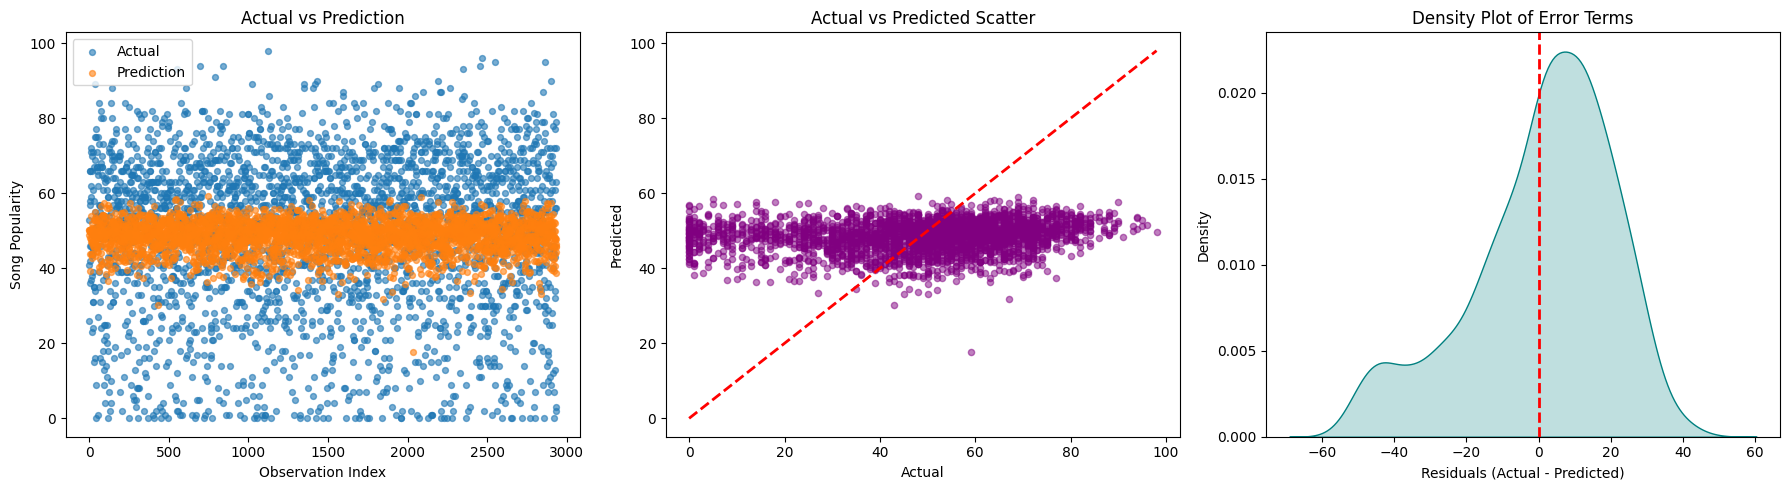

In [77]:
plot_model_diagnostics(y_test, y_pred)

In [78]:
results.append({
"Model": "ElasticNet Regression",
"MAE": mae_test,
"RMSE": rmse_test,
"R2": r2_test,
"Best_Alpha": elasticnet_cv.alpha_,
"Best_l1_ratio": elasticnet_cv.l1_ratio_
})

Elastic Net is now the best-performing model so far, because it has:

- the highest R2

- the lowest RMSE

- the lowest MAE

Elastic Net Regression produced the best performance among the linear models tested so far, achieving the highest R2 and the lowest RMSE and MAE. This suggests that combining L1 and L2 regularization provided a better balance between feature shrinkage and feature selection than Ridge or Lasso alone. However, the improvement over the other regularized models was still very small, and the diagnostic plots remained visually similar. Predictions were still concentrated around the mean popularity range, indicating that the model continued to underfit the data. Therefore, while Elastic Net is currently the best model in the linear regularization family, the overall predictive power remains weak and suggests that the available audio features alone may not be sufficient to explain song popularity effectively.

## Polynomial Regression

In [88]:
poly = PolynomialFeatures(degree=2, include_bias=False)

# Apply polynomial expansion only to continuous scaled columns
X_train_poly_num = poly.fit_transform(X_train_scaled[num_cols])
X_test_poly_num = poly.transform(X_test_scaled[num_cols])

In [89]:
# Convert to DataFrame
poly_feature_names = poly.get_feature_names_out(num_cols)
X_train_poly_num = pd.DataFrame(
    X_train_poly_num,
    columns=poly_feature_names,
    index=X_train_scaled.index
)
X_test_poly_num = pd.DataFrame(
    X_test_poly_num,
    columns=poly_feature_names,
    index=X_test_scaled.index
)

In [90]:
X_train_poly_num

,danceability,energy,audio_valence,song_duration_min,log_duration,log1p_instrumentalness,log1p_speechiness,log1p_liveness,log1p_acousticness,loudness_amp,...,acoustic_vs_energy^2,acoustic_vs_energy dance_valence,acoustic_vs_energy key_sin,acoustic_vs_energy key_cos,dance_valence^2,dance_valence key_sin,dance_valence key_cos,key_sin^2,key_sin key_cos,key_cos^2
8649,1.599193,-0.870805,1.120785,0.031105,0.166533,-0.400245,-0.339611,-0.441538,0.883108,0.199280,...,0.788071,1.629592,-0.609854,0.976400,3.369708,-1.261070,2.019022,0.471939,-0.755593,1.209734
7369,-0.294926,-1.919591,-0.849834,-0.117277,0.004460,-0.400281,-0.741355,-0.449639,-0.629256,-2.082778,...,0.243822,-0.398711,0.029840,0.632455,0.651991,-0.048796,-1.034221,0.003652,0.077402,1.640533
4220,0.614251,1.177254,1.758814,-0.487190,-0.432890,-0.400281,0.109507,-0.852346,-0.501067,1.305315,...,0.773347,-1.563224,0.604130,-0.967235,3.159862,-1.221172,1.955145,0.471939,-0.755593,1.209734
10565,0.923624,1.019711,1.189434,0.314657,0.458072,-0.400281,0.236232,-0.862520,-0.041484,1.055943,...,0.315734,-0.824313,0.386014,-0.618024,2.152104,-1.007801,1.613528,0.471939,-0.755593,1.209734
9939,0.759467,-0.789783,-0.930597,0.211714,0.354823,1.545691,-0.137275,0.495997,-0.961419,-0.199428,...,0.035369,0.115741,-0.254828,0.140139,0.378749,-0.833890,0.458587,1.835974,-1.009671,0.555256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,-0.907358,-1.248908,-1.326337,-0.367203,-0.285382,-0.400281,0.749995,2.134047,1.331229,-0.846634,...,1.917868,-1.730017,-0.951376,1.523191,1.560566,0.858191,-1.373997,0.471939,-0.755593,1.209734
13418,0.096525,-0.087591,0.305078,1.162276,1.215076,-0.394858,-0.514104,1.575063,1.018633,-1.275668,...,0.382267,0.133431,-0.424743,-0.766373,0.046574,-0.148258,-0.267505,0.471939,0.851530,1.536436
5390,1.062526,0.367033,-0.034127,-0.341161,-0.254117,-0.400264,-0.045467,-0.304924,-0.011677,0.610886,...,0.058716,-0.083668,0.166464,-0.266516,0.119223,-0.237204,0.379773,0.471939,-0.755593,1.209734
860,-0.004495,-0.330657,-0.684270,-1.216157,-1.480000,-0.400281,0.225724,-0.555615,0.355750,-0.252231,...,0.087972,-0.179350,-0.366040,-0.221013,0.365647,0.746257,0.450586,1.523051,0.919611,0.555256


In [91]:
# Add binary columns back unchanged
X_train_poly = pd.concat([X_train_poly_num, X_train_scaled[binary_cols]], axis=1)
X_test_poly = pd.concat([X_test_poly_num, X_test_scaled[binary_cols]], axis=1)

In [92]:
print("Original shape :", X_train_scaled.shape)
print("Polynomial shape:", X_train_poly.shape)

Original shape : (11744, 28)
Polynomial shape: (11744, 164)


In [93]:
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

LinearRegression()

In [94]:
y_pred_poly = poly_reg.predict(X_test_poly)
mae_poly, rmse_poly, r2_poly = regression_metrics(y_test, y_pred_poly)

Polynomial Regression
R2 Score : 0.033713813040444296
RMSE     : 19.801622897106327
MAE      : 15.665416264763182


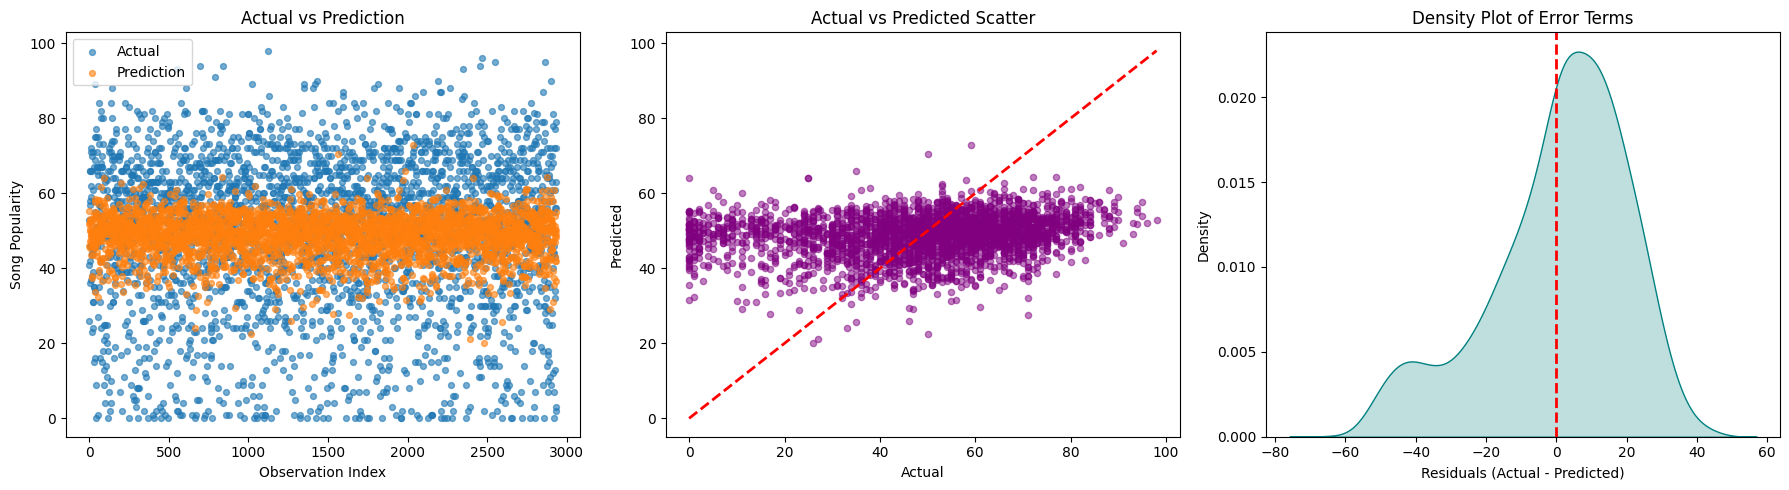

In [95]:
print("Polynomial Regression")
print("R2 Score :", r2_poly)
print("RMSE     :", rmse_poly)
print("MAE      :", mae_poly)

plot_model_diagnostics(y_test, y_pred_poly)

In [96]:
results.append({
"Model": "Polynomial Regression",
"MAE": mae_poly,
"RMSE": rmse_poly,
"R2": r2_poly
})

Polynomial Regression improved all three metrics:

R2 improved the most
RMSE decreased
MAE decreased
That tells us something important:

nonlinear relationships are present in the data, and Polynomial Regression is capturing some of them better than the linear-family regularized models.

Polynomial Regression outperformed Multiple Linear Regression, Ridge, Lasso, and Elastic Net, achieving the highest R2 and the lowest RMSE and MAE among all models tested so far. This indicates that nonlinear relationships exist between the audio features and song popularity, and that polynomial terms help the model capture these patterns better than standard linear models. However, the overall R2 remains low, which suggests that although Polynomial Regression improves performance, the available features still explain only a limited portion of song popularity.

Polynomial Regression improved all three metrics:

- R2 improved the most

- RMSE decreased

- MAE decreased

# Model Comparision

In [97]:
results_df = pd.DataFrame(results)
results_df["RMSE"] = results_df["RMSE"].astype(float)
results_df["MAE"] = results_df["MAE"].astype(float)
results_df["R2"] = results_df["R2"].astype(float)
results_df = results_df.round({
    "MAE": 4,
    "RMSE": 4,
    "R2": 4,
    "Best_Alpha": 4,
    "Best_l1_ratio": 4
})
results_df

,Model,MAE,RMSE,R2,Best_Alpha,Best_l1_ratio
0,Multiple Linear Regression,15.8897,19.9630,0.0179,NaN,NaN
1,Ridge Regression,15.8825,19.9505,0.0191,1.000,NaN
2,Lasso Regression,15.8839,19.9531,0.0189,0.001,NaN
3,ElasticNet Regression,15.8749,19.9429,0.0199,0.001,0.6
4,Polynomial Regression,15.6654,19.8016,0.0337,NaN,NaN


Among all the models tested, Polynomial Regression performed the best because it achieved the highest R2 score and the lowest MAE and RMSE. This indicates that it captured the relationship between the features and song popularity better than the other regression models. However, the overall R2 value remains low, suggesting that even the best model explains only a small portion of the variation in song popularity.

## R2 Score Comparision

In [98]:
results_df = pd.DataFrame(results)
fig = px.bar(
    results_df,
    x="Model",
    y="R2",
    color="R2",
    text="R2",
    title="R2 Score Comparison of Models",
    color_continuous_scale="Blues"
)
fig.update_traces(texttemplate="%{text:.4f}", textposition="outside")
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="R2 Score",
    template="plotly_white"
)
fig.show()

## RMSE Score Comparision

In [99]:
results_df = pd.DataFrame(results)
fig = px.bar(
    results_df,
    x="Model",
    y="RMSE",
    color="RMSE",
    text="RMSE",
    title="Interactive RMSE Score Comparison of Models",
    color_continuous_scale="Blues"
)
fig.update_traces(texttemplate="%{text:.4f}", textposition="outside")
fig.update_layout(
    xaxis_title="Model",
    yaxis_title="RMSE Score",
    template="plotly_white"
)
fig.show()